What you're about to see is a live practical exercise developed by certifiQAte team.

We'll walk through a real hands-on case — applying Metamorphic Testing to an AI-based Sentiment Analysis system: defining metamorphic relations, generating source and follow-up test cases, and validating the results.

The notebook was built from scratch for educational purposes and reflects real-world testing scenarios you'll encounter in AI projects.

*🔒 This material is the intellectual property of CertifiQAte. Screenshots for personal notes — sure. Sharing, reproducing, or "accidentally" uploading to GitHub — not so much. Your karma will thank you.*

In [ ]:
# @title
# ============================================================================
# HANDS-ON EXERCISE: Metamorphic Testing for AI Systems
# ============================================================================

# ==============================================================================
# БЛОК 1: НАЛАШТУВАННЯ СЕРЕДОВИЩА ТА ЗАВАНТАЖЕННЯ БІБЛІОТЕК
# ==============================================================================

print("🔧 КРОК 1: Встановлюємо необхідні бібліотеки")
print("=" * 70)

# Встановлюємо бібліотеки для роботи з AI моделями та тестування
!pip install scikit-learn -q
!pip install transformers -q
!pip install nltk -q

print("\n### Крок 2: Імпортуємо необхідні бібліотеки ###")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from typing import List, Dict, Tuple, Any
import itertools
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown, HTML

# Бібліотеки для машинного навчання
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Бібліотеки для роботи з текстом
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Налаштування візуалізації
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

print("\n✅ Середовище налаштовано, бібліотеки імпортовано.")
print("🧪 Готові до вивчення Metamorphic Testing!")
print("=" * 70)

🔧 КРОК 1: Встановлюємо необхідні бібліотеки

### Крок 2: Імпортуємо необхідні бібліотеки ###

✅ Середовище налаштовано, бібліотеки імпортовано.
🧪 Готові до вивчення Metamorphic Testing!



📚 ТЕОРЕТИЧНЕ ВВЕДЕННЯ: Що таке Метаморфне тестування?



## 🎯 Що таке Metamorphic Testing (MT)?

**Метаморфне тестування** - це техніка тестування, розроблена для подолання
проблеми "oracle problem" (проблеми оракула), коли важко або неможливо
визначити правильний очікуваний результат для тестового випадку.

### 🔑 Ключові концепції:

**1. Oracle Problem (Проблема оракула)**
   - У багатьох AI-системах немає "золотого стандарту" для перевірки результатів
   - Приклад: Як перевірити, чи правильно класифікатор оцінив складне зображення?

**2. Metamorphic Relations (MR) - Метаморфні відношення**
   - Властивості, що описують як зміни вхідних даних впливають на вихідні
   - Не потребують знання точного правильного результату
   - Базуються на відносинах між тестовими випадками

**3. Source Test Case - Вихідний тестовий випадок**
   - Початковий тест, з якого генеруються інші тести
   - Не обов'язково має відомий правильний результат

**4. Follow-up Test Case - Послідовний тестовий випадок**
   - Тест, згенерований з вихідного через застосування MR
   - Результат перевіряється відносно вихідного тесту


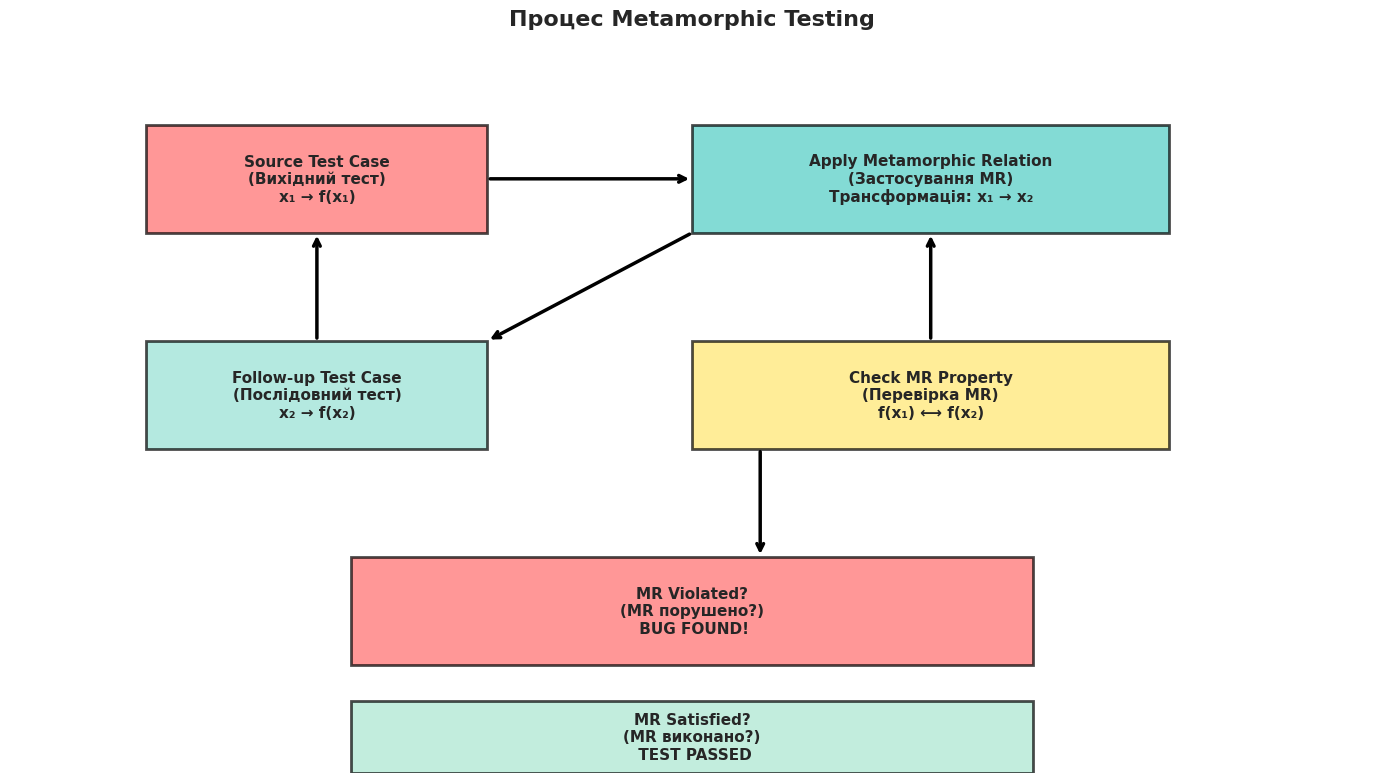


## 📊 Типи Метаморфних відношень:

### Тип 1: Однакові результати (Same Output)
Вхідні дані змінюються, але результат повинен залишитися таким самим.

### Тип 2: Передбачувані зміни результату (Predictable Change)
Вхідні дані змінюються, і результат змінюється передбачуваним чином.


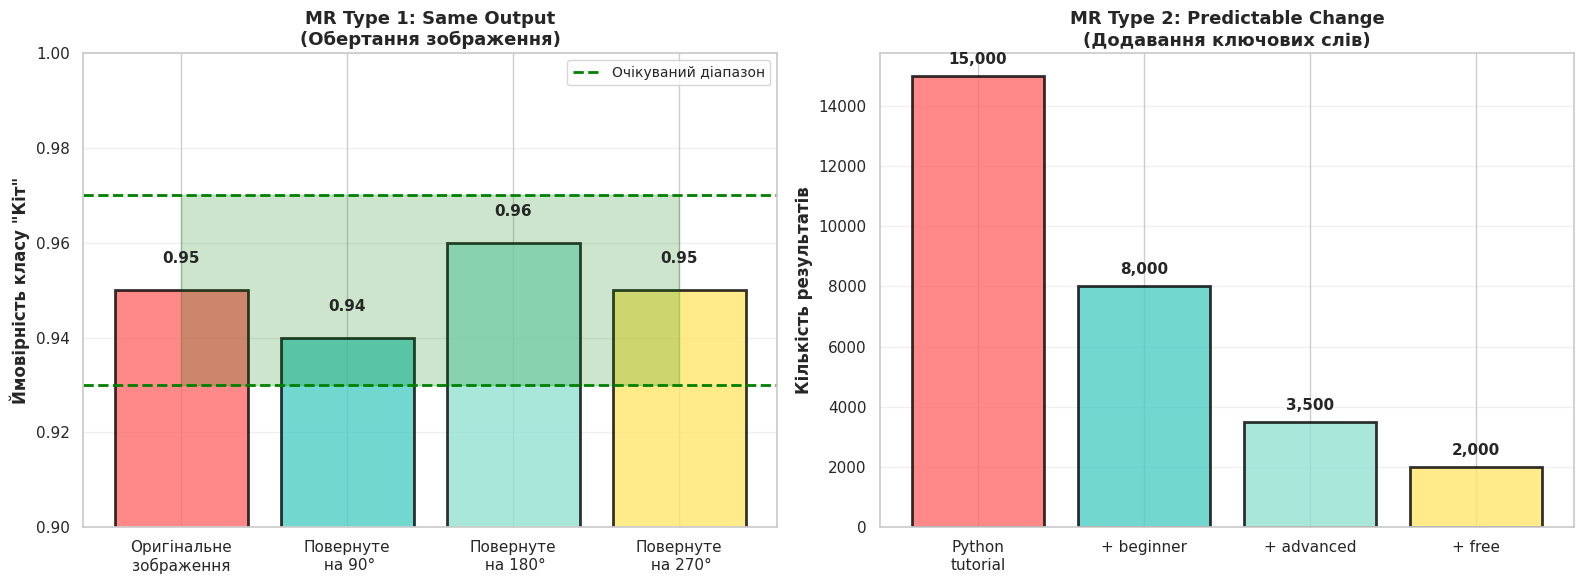

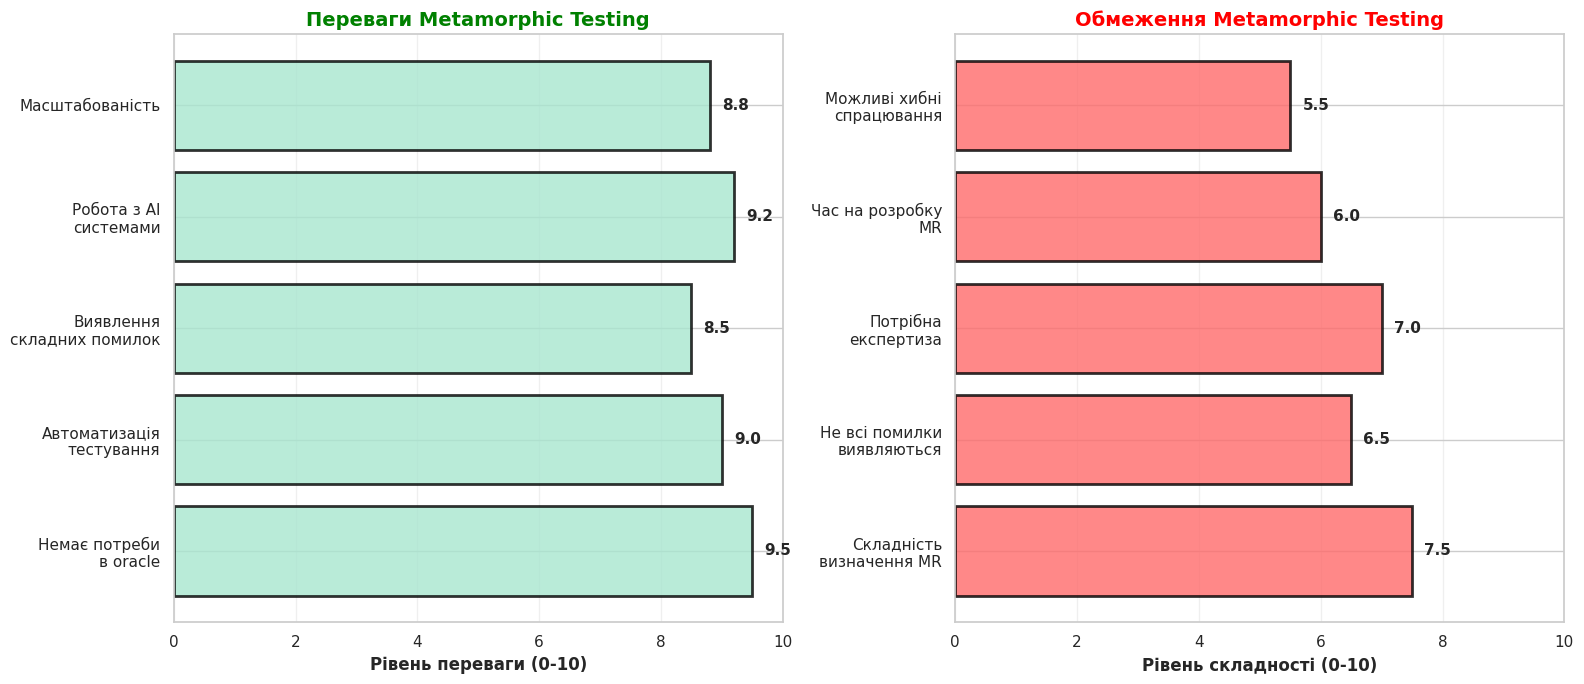


✅ Теоретичне введення завершено!
📝 Далі: Створення AI-системи для тестування


In [ ]:
# @title
# ==============================================================================
# БЛОК 2: ТЕОРЕТИЧНЕ ВВЕДЕННЯ В METAMORPHIC TESTING
# ==============================================================================

print("\n" + "=" * 70)
print("📚 ТЕОРЕТИЧНЕ ВВЕДЕННЯ: Що таке Метаморфне тестування?")
print("=" * 70)

theory_text = """
## 🎯 Що таке Metamorphic Testing (MT)?

**Метаморфне тестування** - це техніка тестування, розроблена для подолання
проблеми "oracle problem" (проблеми оракула), коли важко або неможливо
визначити правильний очікуваний результат для тестового випадку.

### 🔑 Ключові концепції:

**1. Oracle Problem (Проблема оракула)**
   - У багатьох AI-системах немає "золотого стандарту" для перевірки результатів
   - Приклад: Як перевірити, чи правильно класифікатор оцінив складне зображення?

**2. Metamorphic Relations (MR) - Метаморфні відношення**
   - Властивості, що описують як зміни вхідних даних впливають на вихідні
   - Не потребують знання точного правильного результату
   - Базуються на відносинах між тестовими випадками

**3. Source Test Case - Вихідний тестовий випадок**
   - Початковий тест, з якого генеруються інші тести
   - Не обов'язково має відомий правильний результат

**4. Follow-up Test Case - Послідовний тестовий випадок**
   - Тест, згенерований з вихідного через застосування MR
   - Результат перевіряється відносно вихідного тесту
"""

display(Markdown(theory_text))

# Візуалізація 1: Схема процесу Metamorphic Testing

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.axis('off')

# Координати для блоків
blocks = [
    # (x, y, width, height, text, color)
    (0.1, 0.75, 0.25, 0.15, 'Source Test Case\n(Вихідний тест)\nx₁ → f(x₁)', '#FF6B6B'),
    (0.5, 0.75, 0.35, 0.15, 'Apply Metamorphic Relation\n(Застосування MR)\nТрансформація: x₁ → x₂', '#4ECDC4'),
    (0.1, 0.45, 0.25, 0.15, 'Follow-up Test Case\n(Послідовний тест)\nx₂ → f(x₂)', '#95E1D3'),
    (0.5, 0.45, 0.35, 0.15, 'Check MR Property\n(Перевірка MR)\nf(x₁) ⟷ f(x₂)', '#FFE66D'),
    (0.25, 0.15, 0.5, 0.15, 'MR Violated?\n(MR порушено?)\n BUG FOUND!', '#FF6B6B'),
    (0.25, 0.0, 0.5, 0.1, 'MR Satisfied?\n(MR виконано?)\n TEST PASSED', '#A8E6CF'),
]

for x, y, w, h, text, color in blocks:
    rect = plt.Rectangle((x, y), w, h, linewidth=2,
                          edgecolor='black', facecolor=color, alpha=0.7)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=11, weight='bold', wrap=True)

# Стрілки між блоками
arrows = [
    ((0.35, 0.825), (0.5, 0.825)),   # Source → MR
    ((0.5, 0.75), (0.35, 0.60)),     # MR → Follow-up
    ((0.225, 0.6), (0.225, 0.75)), # Follow-up → вгору
    ((0.675, 0.6), (0.675, 0.75)), # Check → вгору
    ((0.55, 0.45), (0.55, 0.30)),     # Check → Decision
]

for start, end in arrows:
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))

plt.title('Процес Metamorphic Testing', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

# Візуалізація 2: Типи метаморфних відношень

theory_text2 = """
## 📊 Типи Метаморфних відношень:

### Тип 1: Однакові результати (Same Output)
Вхідні дані змінюються, але результат повинен залишитися таким самим.

### Тип 2: Передбачувані зміни результату (Predictable Change)
Вхідні дані змінюються, і результат змінюється передбачуваним чином.
"""

display(Markdown(theory_text2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1: Same Output MR
categories = ['Оригінальне\nзображення', 'Повернуте\n на 90°', 'Повернуте\n на 180°', 'Повернуте\n на 270°']
predictions = [0.95, 0.94, 0.96, 0.95]  # Ймовірності класу "кіт"
colors_1 = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D']

bars1 = ax1.bar(categories, predictions, color=colors_1, alpha=0.8, edgecolor='black', linewidth=2)
ax1.axhline(y=0.93, color='green', linestyle='--', linewidth=2, label='Очікуваний діапазон')
ax1.axhline(y=0.97, color='green', linestyle='--', linewidth=2)
ax1.fill_between(range(len(categories)), 0.93, 0.97, alpha=0.2, color='green')
ax1.set_ylabel('Ймовірність класу "Кіт"', fontsize=12, weight='bold')
ax1.set_title('MR Type 1: Same Output\n(Обертання зображення)', fontsize=13, weight='bold')
ax1.set_ylim(0.9, 1.0)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Додаємо значення на стовпчики
for bar, val in zip(bars1, predictions):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11, weight='bold')

# Графік 2: Predictable Change MR
queries = ['Python\ntutorial', '+ beginner', '+ advanced', '+ free']
results_count = [15000, 8000, 3500, 2000]
colors_2 = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D']

bars2 = ax2.bar(queries, results_count, color=colors_2, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('Кількість результатів', fontsize=12, weight='bold')
ax2.set_title('MR Type 2: Predictable Change\n(Додавання ключових слів)', fontsize=13, weight='bold')
ax2.grid(axis='y', alpha=0.3)

# Додаємо значення на стовпчики
for bar, val in zip(bars2, results_count):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 300,
             f'{val:,}', ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

# Візуалізація 3: Переваги vs Обмеження

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Переваги
advantages = [
    'Немає потреби\nв oracle',
    'Автоматизація\nтестування',
    'Виявлення\nскладних помилок',
    'Робота з AI\nсистемами',
    'Масштабованість'
]
adv_scores = [9.5, 9.0, 8.5, 9.2, 8.8]
colors_adv = ['#A8E6CF'] * len(advantages)

bars_adv = ax1.barh(advantages, adv_scores, color=colors_adv, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_xlabel('Рівень переваги (0-10)', fontsize=12, weight='bold')
ax1.set_title('Переваги Metamorphic Testing', fontsize=14, weight='bold', color='green')
ax1.set_xlim(0, 10)
ax1.grid(axis='x', alpha=0.3)

for bar, val in zip(bars_adv, adv_scores):
    width = bar.get_width()
    ax1.text(width + 0.2, bar.get_y() + bar.get_height()/2.,
             f'{val:.1f}', ha='left', va='center', fontsize=11, weight='bold')

# Обмеження
limitations = [
    'Складність\nвизначення MR',
    'Не всі помилки\nвиявляються',
    'Потрібна\nекспертиза',
    'Час на розробку\nMR',
    'Можливі хибні\nспрацювання'
]
lim_scores = [7.5, 6.5, 7.0, 6.0, 5.5]
colors_lim = ['#FF6B6B'] * len(limitations)

bars_lim = ax2.barh(limitations, lim_scores, color=colors_lim, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_xlabel('Рівень складності (0-10)', fontsize=12, weight='bold')
ax2.set_title('Обмеження Metamorphic Testing', fontsize=14, weight='bold', color='red')
ax2.set_xlim(0, 10)
ax2.grid(axis='x', alpha=0.3)

for bar, val in zip(bars_lim, lim_scores):
    width = bar.get_width()
    ax2.text(width + 0.2, bar.get_y() + bar.get_height()/2.,
             f'{val:.1f}', ha='left', va='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("✅ Теоретичне введення завершено!")
print("📝 Далі: Створення AI-системи для тестування")
print("=" * 70)


🤖 СТВОРЕННЯ AI-СИСТЕМИ: Sentiment Analysis Classifier



## 📝 Система для тестування: Аналізатор тональності тексту

Ми створимо **класифікатор тональності тексту** (Sentiment Analysis), який
визначає емоційне забарвлення тексту: позитивне, негативне або нейтральне.

**Чому саме цю систему?**
- ✓ Реальна AI-задача з практичним застосуванням
- ✓ Легко придумати метаморфні відношення
- ✓ Простота перевірки результатів
- ✓ Можливість демонструвати різні типи MR

**Що буде робити наша система:**
- Приймає текст (речення або відгук)
- Аналізує тональність
- Повертає: POSITIVE, NEGATIVE, або NEUTRAL
- Додатково: рівень впевненості (0-1)



### Крок 1: Створюємо простий Sentiment Analyzer ###

✅ Sentiment Analyzer створено!

### Крок 2: Тестуємо базову функціональність ###

📝 Text: 'This movie is absolutely amazing and wonderful!'
   → Sentiment: POSITIVE (Confidence: 0.95)
   → Scores: +2.5 / -0.0

📝 Text: 'I hate this terrible and awful product.'
   → Sentiment: NEGATIVE (Confidence: 0.95)
   → Scores: +0.0 / -3.0

📝 Text: 'The weather is okay today.'
   → Sentiment: NEUTRAL (Confidence: 0.50)
   → Scores: +0.0 / -0.0

📝 Text: 'Very good service, really happy with it!'
   → Sentiment: POSITIVE (Confidence: 0.95)
   → Scores: +3.0 / -0.0

📝 Text: 'Disappointed with the poor quality.'
   → Sentiment: NEGATIVE (Confidence: 0.95)
   → Scores: +0.0 / -2.0


### 📊 Зведена таблиця результатів ###



,text,sentiment,confidence,positive_score,negative_score
0,This movie is absolutely amazing and wonderful!,POSITIVE,0.95,2.5,0.0
1,I hate this terrible and awful product.,NEGATIVE,0.95,0.0,3.0
2,The weather is okay today.,NEUTRAL,0.50,0.0,0.0
3,"Very good service, really happy with it!",POSITIVE,0.95,3.0,0.0
4,Disappointed with the poor quality.,NEGATIVE,0.95,0.0,2.0



### 📊 Візуалізація роботи системи ###



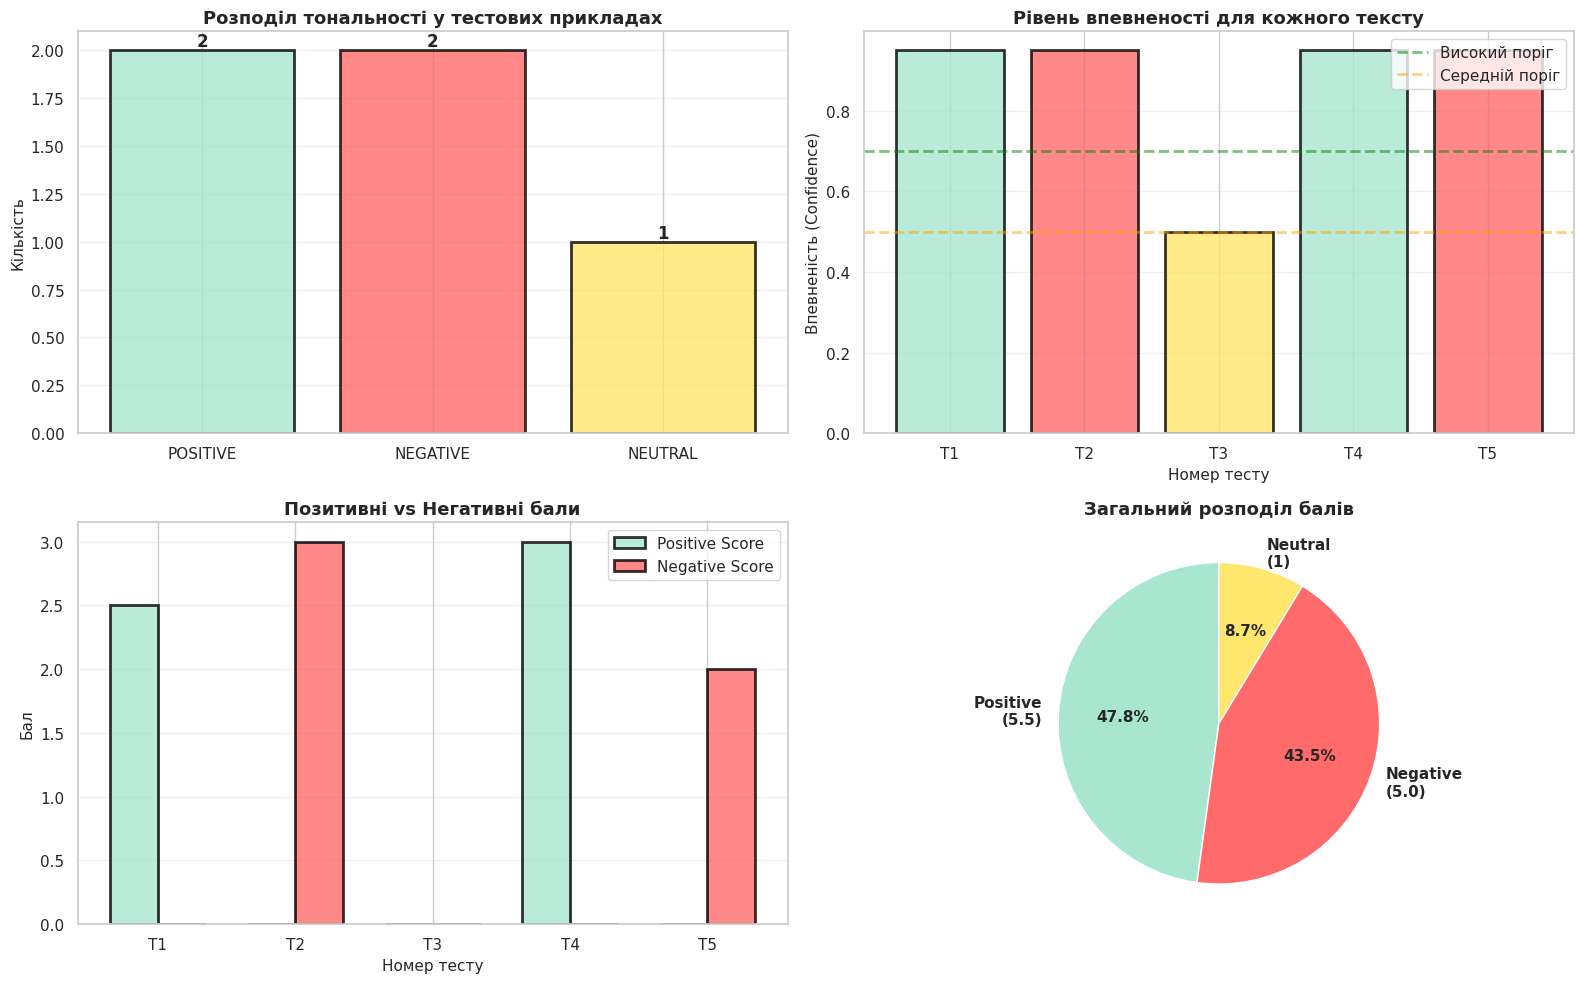


✅ AI-система створена та протестована!
📝 Далі: Визначення Метаморфних Відношень (MR)


In [ ]:
# @title
# ==============================================================================
# БЛОК 3: СТВОРЕННЯ AI-СИСТЕМИ ДЛЯ ТЕСТУВАННЯ
# ==============================================================================

print("\n" + "=" * 70)
print("🤖 СТВОРЕННЯ AI-СИСТЕМИ: Sentiment Analysis Classifier")
print("=" * 70)

intro_text = """
## 📝 Система для тестування: Аналізатор тональності тексту

Ми створимо **класифікатор тональності тексту** (Sentiment Analysis), який
визначає емоційне забарвлення тексту: позитивне, негативне або нейтральне.

**Чому саме цю систему?**
- ✓ Реальна AI-задача з практичним застосуванням
- ✓ Легко придумати метаморфні відношення
- ✓ Простота перевірки результатів
- ✓ Можливість демонструвати різні типи MR

**Що буде робити наша система:**
- Приймає текст (речення або відгук)
- Аналізує тональність
- Повертає: POSITIVE, NEGATIVE, або NEUTRAL
- Додатково: рівень впевненості (0-1)
"""

display(Markdown(intro_text))

print("\n### Крок 1: Створюємо простий Sentiment Analyzer ###\n")

class SimpleSentimentAnalyzer:
    """
    Простий аналізатор тональності тексту на основі словника.

    Ця система демонструє типову AI-задачу, яка добре підходить для MT,
    оскільки "правильний" результат часто суб'єктивний.
    """

    def __init__(self):
        # Словники позитивних та негативних слів
        self.positive_words = {
            'good', 'great', 'excellent', 'amazing', 'wonderful', 'fantastic',
            'love', 'best', 'perfect', 'beautiful', 'awesome', 'happy',
            'brilliant', 'outstanding', 'superb', 'magnificent', 'glad',
            'enjoy', 'pleased', 'delighted', 'terrific', 'fabulous'
        }

        self.negative_words = {
            'bad', 'terrible', 'awful', 'horrible', 'worst', 'poor',
            'hate', 'disappointing', 'unfortunate', 'sad', 'angry',
            'disgusting', 'pathetic', 'useless', 'waste', 'boring',
            'annoying', 'frustrated', 'upset', 'disappointed', 'ugly'
        }

        # Модифікатори (підсилювачі та послаблювачі)
        self.intensifiers = {'very', 'really', 'extremely', 'absolutely', 'totally'}
        self.diminishers = {'slightly', 'somewhat', 'fairly', 'quite', 'rather'}

    def analyze(self, text: str) -> Dict[str, Any]:
        """
        Аналізує тональність тексту.

        Args:
            text: Вхідний текст для аналізу

        Returns:
            Dict з результатами: sentiment, confidence, scores
        """
        # Приводимо до нижнього регістру та розбиваємо на слова
        words = text.lower().split()

        # Підрахунок позитивних та негативних слів
        positive_score = 0
        negative_score = 0

        for i, word in enumerate(words):
            # Очищаємо слово від пунктуації
            clean_word = ''.join(c for c in word if c.isalnum())

            # Перевіряємо модифікатори
            multiplier = 1.0
            if i > 0:
                prev_word = ''.join(c for c in words[i-1] if c.isalnum())
                if prev_word in self.intensifiers:
                    multiplier = 1.5
                elif prev_word in self.diminishers:
                    multiplier = 0.5

            # Підрахунок
            if clean_word in self.positive_words:
                positive_score += 1 * multiplier
            elif clean_word in self.negative_words:
                negative_score += 1 * multiplier

        # Визначення результату
        total_score = positive_score + negative_score

        if total_score == 0:
            sentiment = "NEUTRAL"
            confidence = 0.5
        elif positive_score > negative_score:
            sentiment = "POSITIVE"
            confidence = min(0.95, 0.5 + (positive_score - negative_score) / (total_score + 1))
        else:
            sentiment = "NEGATIVE"
            confidence = min(0.95, 0.5 + (negative_score - positive_score) / (total_score + 1))

        return {
            'text': text,
            'sentiment': sentiment,
            'confidence': confidence,
            'positive_score': positive_score,
            'negative_score': negative_score,
            'total_words': len(words)
        }

    def batch_analyze(self, texts: List[str]) -> List[Dict[str, Any]]:
        """Аналізує список текстів."""
        return [self.analyze(text) for text in texts]


# Створюємо екземпляр аналізатора
analyzer = SimpleSentimentAnalyzer()

print("✅ Sentiment Analyzer створено!")

print("\n### Крок 2: Тестуємо базову функціональність ###\n")

# Приклади тестових текстів
test_texts = [
    "This movie is absolutely amazing and wonderful!",
    "I hate this terrible and awful product.",
    "The weather is okay today.",
    "Very good service, really happy with it!",
    "Disappointed with the poor quality."
]

# Аналізуємо тексти
results = []
for text in test_texts:
    result = analyzer.analyze(text)
    results.append(result)
    print(f"📝 Text: '{text}'")
    print(f"   → Sentiment: {result['sentiment']} (Confidence: {result['confidence']:.2f})")
    print(f"   → Scores: +{result['positive_score']:.1f} / -{result['negative_score']:.1f}\n")

# Створюємо DataFrame для зручного перегляду
df_results = pd.DataFrame(results)

print("\n### 📊 Зведена таблиця результатів ###\n")
display(df_results[['text', 'sentiment', 'confidence', 'positive_score', 'negative_score']])

# Візуалізація результатів
print("\n### 📊 Візуалізація роботи системи ###\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Графік 1: Розподіл тональності
ax1 = axes[0, 0]
sentiment_counts = df_results['sentiment'].value_counts()
colors_sent = {'POSITIVE': '#A8E6CF', 'NEGATIVE': '#FF6B6B', 'NEUTRAL': '#FFE66D'}
bars1 = ax1.bar(sentiment_counts.index, sentiment_counts.values,
                color=[colors_sent[s] for s in sentiment_counts.index],
                alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_title('Розподіл тональності у тестових прикладах', fontsize=13, weight='bold')
ax1.set_ylabel('Кількість', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=12, weight='bold')

# Графік 2: Рівень впевненості
ax2 = axes[0, 1]
x_pos = np.arange(len(df_results))
colors_conf = [colors_sent[s] for s in df_results['sentiment']]
bars2 = ax2.bar(x_pos, df_results['confidence'], color=colors_conf,
                alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_title('Рівень впевненості для кожного тексту', fontsize=13, weight='bold')
ax2.set_ylabel('Впевненість (Confidence)', fontsize=11)
ax2.set_xlabel('Номер тесту', fontsize=11)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'T{i+1}' for i in x_pos])
ax2.axhline(y=0.7, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Високий поріг')
ax2.axhline(y=0.5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Середній поріг')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Графік 3: Порівняння позитивних vs негативних балів
ax3 = axes[1, 0]
x_pos = np.arange(len(df_results))
width = 0.35
bars3_pos = ax3.bar(x_pos - width/2, df_results['positive_score'], width,
                    label='Positive Score', color='#A8E6CF', alpha=0.8, edgecolor='black', linewidth=2)
bars3_neg = ax3.bar(x_pos + width/2, df_results['negative_score'], width,
                    label='Negative Score', color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_title('Позитивні vs Негативні бали', fontsize=13, weight='bold')
ax3.set_ylabel('Бал', fontsize=11)
ax3.set_xlabel('Номер тесту', fontsize=11)
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f'T{i+1}' for i in x_pos])
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Графік 4: Співвідношення балів (як pie chart для останнього тексту)
ax4 = axes[1, 1]
total_pos = df_results['positive_score'].sum()
total_neg = df_results['negative_score'].sum()
total_neu = len(df_results[df_results['sentiment'] == 'NEUTRAL'])

pie_data = [total_pos, total_neg, total_neu if total_neu > 0 else 0.1]
pie_labels = [f'Positive\n({total_pos:.1f})',
              f'Negative\n({total_neg:.1f})',
              f'Neutral\n({total_neu})']
pie_colors = ['#A8E6CF', '#FF6B6B', '#FFE66D']

wedges, texts, autotexts = ax4.pie(pie_data, labels=pie_labels, colors=pie_colors,
                                     autopct='%1.1f%%', startangle=90,
                                     textprops={'fontsize': 11, 'weight': 'bold'})
ax4.set_title('Загальний розподіл балів', fontsize=13, weight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("✅ AI-система створена та протестована!")
print("📝 Далі: Визначення Метаморфних Відношень (MR)")
print("=" * 70)


🔍 ВИЗНАЧЕННЯ МЕТАМОРФНИХ ВІДНОШЕНЬ (MR)



## 🎯 Що робимо в цьому блоці?

Визначаємо **метаморфні відношення** для нашого Sentiment Analyzer.
Це ключовий крок у метаморфному тестуванні!

**Пам'ятаємо:** MR описують, як зміни входу повинні впливати на вихід,
без необхідності знати "правильну" відповідь.

---

## 📋 Наші Метаморфні Відношення

Ми визначимо **6 MR** для тестування Sentiment Analyzer:
- 3 MR де результат **залишається таким самим** (Same Output)
- 3 MR де результат **змінюється передбачувано** (Predictable Change)



### 📊 Візуалізація: Огляд всіх MR ###



,ID,Назва,Тип,Опис трансформації,Очікування
0,MR1,Case Invariance,Same Output,Зміна регістру букв (upper/lower),Sentiment не змінюється
1,MR2,Punctuation Invariance,Same Output,Додавання/видалення пунктуації,Sentiment не змінюється
2,MR3,Whitespace Invariance,Same Output,Додавання пробілів між словами,Sentiment не змінюється
3,MR4,Negation Change,Predictable Change,"Додавання заперечення (not, never)",Sentiment змінюється на протилежний
4,MR5,Intensifier Addition,Predictable Change,"Додавання підсилювачів (very, really)",Confidence збільшується
5,MR6,Sentiment Word Addition,Predictable Change,Додавання sentiment слів,Sentiment підсилюється у напрямку


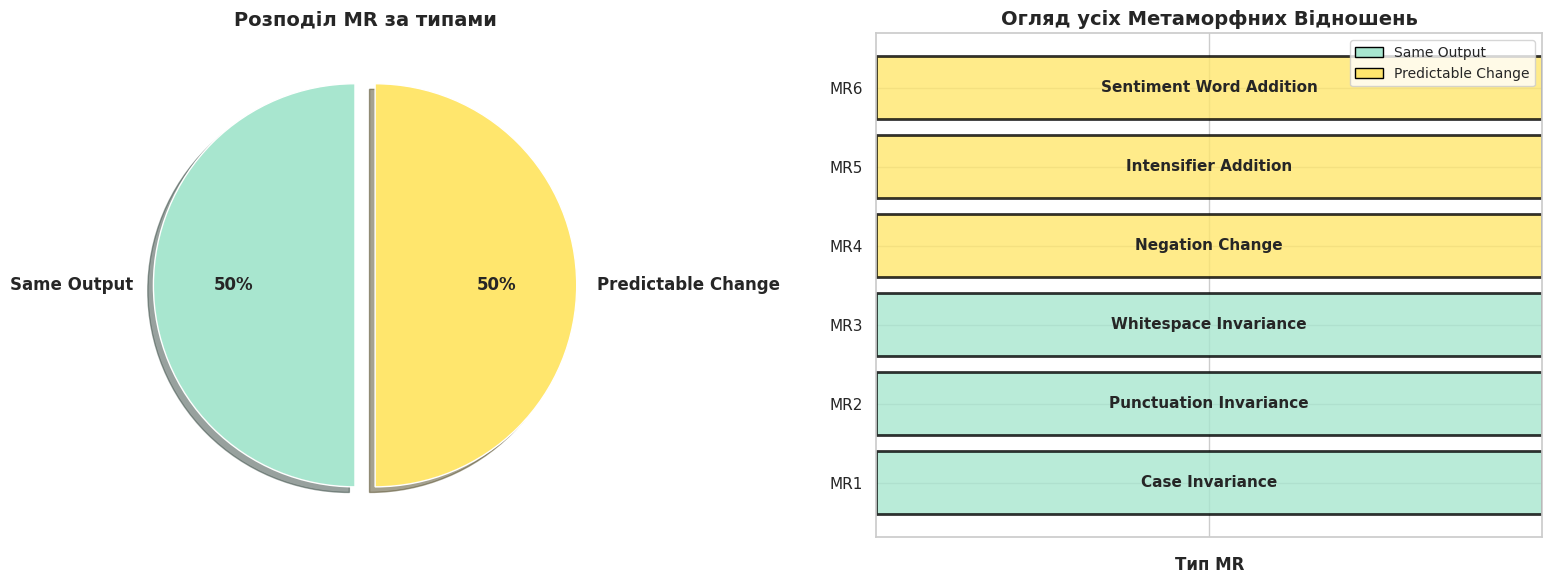


📝 ДЕТАЛЬНИЙ ОПИС КОЖНОГО MR



### 🔹 MR1: Case Invariance (Інваріантність регістру)

**Тип:** Same Output

**Опис:**
Зміна регістру букв у тексті (UPPER → lower → Title Case) не повинна
впливати на визначення тональності.

**Трансформація:**
- Source: "This movie is great"
- Follow-up 1: "THIS MOVIE IS GREAT"
- Follow-up 2: "this movie is great"
- Follow-up 3: "This Movie Is Great"

**Очікування:**
`sentiment(source) == sentiment(follow-up)`

**Обґрунтування:**
Тональність залежить від слів, а не від їх регістру. Система повинна
розпізнавати "GREAT" та "great" як одне й те саме слово.

**Приклад порушення:**
Якщо система має окремі словники для великих і малих букв, вона може
неправильно класифікувати текст у верхньому регістрі.



### 🔹 MR2: Punctuation Invariance (Інваріантність пунктуації)

**Тип:** Same Output

**Опис:**
Додавання або видалення пунктуації (крапок, ком, знаків оклику) не повинно
суттєво змінювати тональність, якщо не змінюється значення речення.

**Трансформація:**
- Source: "This is amazing"
- Follow-up 1: "This is amazing!"
- Follow-up 2: "This is amazing!!!"
- Follow-up 3: "This, is, amazing."

**Очікування:**
`sentiment(source) == sentiment(follow-up)`
`|confidence(source) - confidence(follow-up)| < threshold` (наприклад, < 0.1)

**Обґрунтування:**
Пунктуація може додавати емоційності, але не змінює основну тональність слів.
"Amazing" залишається позитивним словом з крапкою чи знаком оклику.

**Примітка:**
Деякі системи можуть підвищувати впевненість при наявності знаків оклику,
що є прийнятним, якщо sentiment залишається тим самим.



### 🔹 MR3: Whitespace Invariance (Інваріантність пробілів)

**Тип:** Same Output

**Опис:**
Додавання зайвих пробілів між словами або на початку/кінці тексту не повинно
впливати на визначення тональності.

**Трансформація:**
- Source: "Good service"
- Follow-up 1: "Good  service" (подвійний пробіл)
- Follow-up 2: "  Good service  " (пробіли на початку/кінці)
- Follow-up 3: "Good     service" (багато пробілів)

**Очікування:**
`sentiment(source) == sentiment(follow-up)`

**Обґрунтування:**
Пробіли - це технічні символи форматування, які не несуть смислового
навантаження і не повинні впливати на аналіз тональності.

**Приклад порушення:**
Погано розроблений парсер може розділити "Good  service" на ["Good", "", "service"]
і збентежитись через порожній елемент.



----------------------------------------------------------------------



### 🔸 MR4: Negation Change (Зміна через заперечення)

**Тип:** Predictable Change

**Опис:**
Додавання заперечення (not, never, no) перед sentiment словом повинно
змінити тональність на протилежну.

**Трансформація:**
- Source: "This is good"
- Follow-up: "This is not good"

**Очікування:**
`sentiment(source) = POSITIVE → sentiment(follow-up) = NEGATIVE`
`sentiment(source) = NEGATIVE → sentiment(follow-up) = POSITIVE`

**Обґрунтування:**
Заперечення інвертує значення: "good" (позитивне) → "not good" (негативне).
Це фундаментальна властивість природної мови.

**Складність:**
- Подвійне заперечення: "not bad" може означати позитивне
- Контекст: "not just good, but excellent" залишається позитивним

**Важливо:**
Цей MR може виявити, чи система правильно обробляє заперечення,
що є поширеною проблемою у sentiment analysis.



### 🔸 MR5: Intensifier Addition (Додавання підсилювачів)

**Тип:** Predictable Change

**Опис:**
Додавання слів-підсилювачів (very, really, extremely, absolutely) перед
sentiment словом повинно збільшити впевненість у класифікації.

**Трансформація:**
- Source: "This is good"
- Follow-up: "This is very good"

**Очікування:**
`sentiment(source) == sentiment(follow-up)`
`confidence(follow-up) > confidence(source)`

**Обґрунтування:**
Підсилювачі збільшують інтенсивність емоції, але не змінюють її напрямок.
"Very good" - це все ще позитивно, але з більшою силою.

**Приклад:**
- "good" (confidence: 0.7) → "very good" (confidence: 0.85)
- "bad" (confidence: 0.6) → "extremely bad" (confidence: 0.9)

**Метрики перевірки:**
`confidence_increase = confidence(follow-up) - confidence(source)`
Очікуємо: `confidence_increase > 0.05` (принаймні 5% збільшення)



### 🔸 MR6: Sentiment Word Addition (Додавання sentiment слів)

**Тип:** Predictable Change

**Опис:**
Додавання додаткових слів з тією самою тональністю повинно підсилити
загальну тональність у цьому напрямку (збільшити score і confidence).

**Трансформація:**
- Source: "This is good"
- Follow-up: "This is good and excellent"

**Очікування:**
`sentiment(source) == sentiment(follow-up)` (той самий напрямок)
`score(follow-up) > score(source)` (більший бал)
`confidence(follow-up) >= confidence(source)` (вища або рівна впевненість)

**Обґрунтування:**
Більше позитивних слів → сильніша позитивна тональність.
Більше негативних слів → сильніша негативна тональність.

**Приклад:**
- "good" (pos_score: 1) → "good and great" (pos_score: 2)
- "bad" (neg_score: 1) → "bad and terrible" (neg_score: 2)

**Примітка:**
Цей MR може виявити, чи система правильно агрегує множинні sentiment слова,
а не просто рахує перше слово.



✅ Усі 6 Метаморфних Відношень визначено!
📊 Далі: Генерація Source Test Cases


In [ ]:
# @title
# ==============================================================================
# БЛОК 4: ВИЗНАЧЕННЯ МЕТАМОРФНИХ ВІДНОШЕНЬ (METAMORPHIC RELATIONS)
# ==============================================================================

print("\n" + "=" * 70)
print("🔍 ВИЗНАЧЕННЯ МЕТАМОРФНИХ ВІДНОШЕНЬ (MR)")
print("=" * 70)

mr_intro = """
## 🎯 Що робимо в цьому блоці?

Визначаємо **метаморфні відношення** для нашого Sentiment Analyzer.
Це ключовий крок у метаморфному тестуванні!

**Пам'ятаємо:** MR описують, як зміни входу повинні впливати на вихід,
без необхідності знати "правильну" відповідь.

---

## 📋 Наші Метаморфні Відношення

Ми визначимо **6 MR** для тестування Sentiment Analyzer:
- 3 MR де результат **залишається таким самим** (Same Output)
- 3 MR де результат **змінюється передбачувано** (Predictable Change)
"""

display(Markdown(mr_intro))

print("\n### 📊 Візуалізація: Огляд всіх MR ###\n")

# Створюємо таблицю з MR
mr_data = {
    'ID': ['MR1', 'MR2', 'MR3', 'MR4', 'MR5', 'MR6'],
    'Назва': [
        'Case Invariance',
        'Punctuation Invariance',
        'Whitespace Invariance',
        'Negation Change',
        'Intensifier Addition',
        'Sentiment Word Addition'
    ],
    'Тип': [
        'Same Output',
        'Same Output',
        'Same Output',
        'Predictable Change',
        'Predictable Change',
        'Predictable Change'
    ],
    'Опис трансформації': [
        'Зміна регістру букв (upper/lower)',
        'Додавання/видалення пунктуації',
        'Додавання пробілів між словами',
        'Додавання заперечення (not, never)',
        'Додавання підсилювачів (very, really)',
        'Додавання sentiment слів'
    ],
    'Очікування': [
        'Sentiment не змінюється',
        'Sentiment не змінюється',
        'Sentiment не змінюється',
        'Sentiment змінюється на протилежний',
        'Confidence збільшується',
        'Sentiment підсилюється у напрямку'
    ]
}

df_mr = pd.DataFrame(mr_data)

# Кольорове кодування
def highlight_type(val):
    if val == 'Same Output':
        return 'background-color: #A8E6CF'
    elif val == 'Predictable Change':
        return 'background-color: #FFE66D'
    return ''

styled_df = df_mr.style.applymap(highlight_type, subset=['Тип'])
display(styled_df)

# Візуалізація розподілу MR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1: Кількість MR за типом
type_counts = df_mr['Тип'].value_counts()
colors_type = ['#A8E6CF', '#FFE66D']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax1.pie(type_counts.values, labels=type_counts.index,
                                     colors=colors_type, autopct='%1.0f%%',
                                     startangle=90, explode=explode,
                                     textprops={'fontsize': 12, 'weight': 'bold'},
                                     shadow=True)
ax1.set_title('Розподіл MR за типами', fontsize=14, weight='bold')

# Графік 2: Всі MR по порядку
mr_ids = df_mr['ID']
mr_types_numeric = [1 if t == 'Same Output' else 2 for t in df_mr['Тип']]
colors_bars = ['#A8E6CF' if t == 'Same Output' else '#FFE66D' for t in df_mr['Тип']]

bars = ax2.barh(mr_ids, [1]*len(mr_ids), color=colors_bars, alpha=0.8,
                edgecolor='black', linewidth=2)
ax2.set_xlabel('Тип MR', fontsize=12, weight='bold')
ax2.set_title('Огляд усіх Метаморфних Відношень', fontsize=14, weight='bold')
ax2.set_xticks([0.5])
ax2.set_xticklabels([''])
ax2.set_xlim(0, 1)

# Додаємо текстові мітки
for i, (bar, name) in enumerate(zip(bars, df_mr['Назва'])):
    ax2.text(0.5, bar.get_y() + bar.get_height()/2., name,
             ha='center', va='center', fontsize=11, weight='bold')

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#A8E6CF', edgecolor='black', label='Same Output'),
    Patch(facecolor='#FFE66D', edgecolor='black', label='Predictable Change')
]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("📝 ДЕТАЛЬНИЙ ОПИС КОЖНОГО MR")
print("=" * 70)

# MR1
mr1_text = """
### 🔹 MR1: Case Invariance (Інваріантність регістру)

**Тип:** Same Output

**Опис:**
Зміна регістру букв у тексті (UPPER → lower → Title Case) не повинна
впливати на визначення тональності.

**Трансформація:**
- Source: "This movie is great"
- Follow-up 1: "THIS MOVIE IS GREAT"
- Follow-up 2: "this movie is great"
- Follow-up 3: "This Movie Is Great"

**Очікування:**
`sentiment(source) == sentiment(follow-up)`

**Обґрунтування:**
Тональність залежить від слів, а не від їх регістру. Система повинна
розпізнавати "GREAT" та "great" як одне й те саме слово.

**Приклад порушення:**
Якщо система має окремі словники для великих і малих букв, вона може
неправильно класифікувати текст у верхньому регістрі.
"""

display(Markdown(mr1_text))

# MR2
mr2_text = """
### 🔹 MR2: Punctuation Invariance (Інваріантність пунктуації)

**Тип:** Same Output

**Опис:**
Додавання або видалення пунктуації (крапок, ком, знаків оклику) не повинно
суттєво змінювати тональність, якщо не змінюється значення речення.

**Трансформація:**
- Source: "This is amazing"
- Follow-up 1: "This is amazing!"
- Follow-up 2: "This is amazing!!!"
- Follow-up 3: "This, is, amazing."

**Очікування:**
`sentiment(source) == sentiment(follow-up)`
`|confidence(source) - confidence(follow-up)| < threshold` (наприклад, < 0.1)

**Обґрунтування:**
Пунктуація може додавати емоційності, але не змінює основну тональність слів.
"Amazing" залишається позитивним словом з крапкою чи знаком оклику.

**Примітка:**
Деякі системи можуть підвищувати впевненість при наявності знаків оклику,
що є прийнятним, якщо sentiment залишається тим самим.
"""

display(Markdown(mr2_text))

# MR3
mr3_text = """
### 🔹 MR3: Whitespace Invariance (Інваріантність пробілів)

**Тип:** Same Output

**Опис:**
Додавання зайвих пробілів між словами або на початку/кінці тексту не повинно
впливати на визначення тональності.

**Трансформація:**
- Source: "Good service"
- Follow-up 1: "Good  service" (подвійний пробіл)
- Follow-up 2: "  Good service  " (пробіли на початку/кінці)
- Follow-up 3: "Good     service" (багато пробілів)

**Очікування:**
`sentiment(source) == sentiment(follow-up)`

**Обґрунтування:**
Пробіли - це технічні символи форматування, які не несуть смислового
навантаження і не повинні впливати на аналіз тональності.

**Приклад порушення:**
Погано розроблений парсер може розділити "Good  service" на ["Good", "", "service"]
і збентежитись через порожній елемент.
"""

display(Markdown(mr3_text))

print("\n" + "-" * 70)

# MR4
mr4_text = """
### 🔸 MR4: Negation Change (Зміна через заперечення)

**Тип:** Predictable Change

**Опис:**
Додавання заперечення (not, never, no) перед sentiment словом повинно
змінити тональність на протилежну.

**Трансформація:**
- Source: "This is good"
- Follow-up: "This is not good"

**Очікування:**
`sentiment(source) = POSITIVE → sentiment(follow-up) = NEGATIVE`
`sentiment(source) = NEGATIVE → sentiment(follow-up) = POSITIVE`

**Обґрунтування:**
Заперечення інвертує значення: "good" (позитивне) → "not good" (негативне).
Це фундаментальна властивість природної мови.

**Складність:**
- Подвійне заперечення: "not bad" може означати позитивне
- Контекст: "not just good, but excellent" залишається позитивним

**Важливо:**
Цей MR може виявити, чи система правильно обробляє заперечення,
що є поширеною проблемою у sentiment analysis.
"""

display(Markdown(mr4_text))

# MR5
mr5_text = """
### 🔸 MR5: Intensifier Addition (Додавання підсилювачів)

**Тип:** Predictable Change

**Опис:**
Додавання слів-підсилювачів (very, really, extremely, absolutely) перед
sentiment словом повинно збільшити впевненість у класифікації.

**Трансформація:**
- Source: "This is good"
- Follow-up: "This is very good"

**Очікування:**
`sentiment(source) == sentiment(follow-up)`
`confidence(follow-up) > confidence(source)`

**Обґрунтування:**
Підсилювачі збільшують інтенсивність емоції, але не змінюють її напрямок.
"Very good" - це все ще позитивно, але з більшою силою.

**Приклад:**
- "good" (confidence: 0.7) → "very good" (confidence: 0.85)
- "bad" (confidence: 0.6) → "extremely bad" (confidence: 0.9)

**Метрики перевірки:**
`confidence_increase = confidence(follow-up) - confidence(source)`
Очікуємо: `confidence_increase > 0.05` (принаймні 5% збільшення)
"""

display(Markdown(mr5_text))

# MR6
mr6_text = """
### 🔸 MR6: Sentiment Word Addition (Додавання sentiment слів)

**Тип:** Predictable Change

**Опис:**
Додавання додаткових слів з тією самою тональністю повинно підсилити
загальну тональність у цьому напрямку (збільшити score і confidence).

**Трансформація:**
- Source: "This is good"
- Follow-up: "This is good and excellent"

**Очікування:**
`sentiment(source) == sentiment(follow-up)` (той самий напрямок)
`score(follow-up) > score(source)` (більший бал)
`confidence(follow-up) >= confidence(source)` (вища або рівна впевненість)

**Обґрунтування:**
Більше позитивних слів → сильніша позитивна тональність.
Більше негативних слів → сильніша негативна тональність.

**Приклад:**
- "good" (pos_score: 1) → "good and great" (pos_score: 2)
- "bad" (neg_score: 1) → "bad and terrible" (neg_score: 2)

**Примітка:**
Цей MR може виявити, чи система правильно агрегує множинні sentiment слова,
а не просто рахує перше слово.
"""

display(Markdown(mr6_text))

print("\n" + "=" * 70)
print("✅ Усі 6 Метаморфних Відношень визначено!")
print("📊 Далі: Генерація Source Test Cases")
print("=" * 70)


📝 ГЕНЕРАЦІЯ SOURCE TEST CASES



## 🎯 Що таке Source Test Cases?

**Source Test Cases** - це початкові тестові випадки, з яких ми будемо
генерувати follow-up тести, застосовуючи метаморфні відношення.

**Важливо:**
У метаморфному тестуванні Source TC **не обов'язково** мають відомий
правильний результат! Це одна з ключових переваг MT - ми можемо тестувати
без "oracle" (еталонної відповіді).

**Наша стратегія генерації:**
1. Створюємо різноманітні тексти з різною тональністю
2. Охоплюємо різні довжини та складність
3. Включаємо edge cases (граничні випадки)
4. Забезпечуємо баланс між позитивними, негативними та нейтральними текстами



### Крок 1: Створюємо набір Source Test Cases ###

✅ Створено 35 Source Test Cases

### 📊 Таблиця Source Test Cases ###



,id,category,text
0,STC_001,positive,This product is excellent and amazing
1,STC_002,positive,I love this wonderful service
2,STC_003,positive,"Great experience, highly recommend"
3,STC_004,positive,Absolutely fantastic quality
4,STC_005,positive,Very happy with the results
5,STC_006,positive,Outstanding performance and beautiful design
6,STC_007,positive,Perfect solution for my needs
7,STC_008,positive,Really enjoyed every moment
8,STC_009,negative,This is terrible and disappointing
9,STC_010,negative,I hate this awful product



... та ще 20 тестів


### 📊 Статистика Source Test Cases за категоріями ###



,Категорія,Кількість
0,positive,8
1,negative,8
2,neutral,8
3,edge_cases,6
4,mixed,5



### 📊 Візуалізація 1: Розподіл Source Test Cases ###



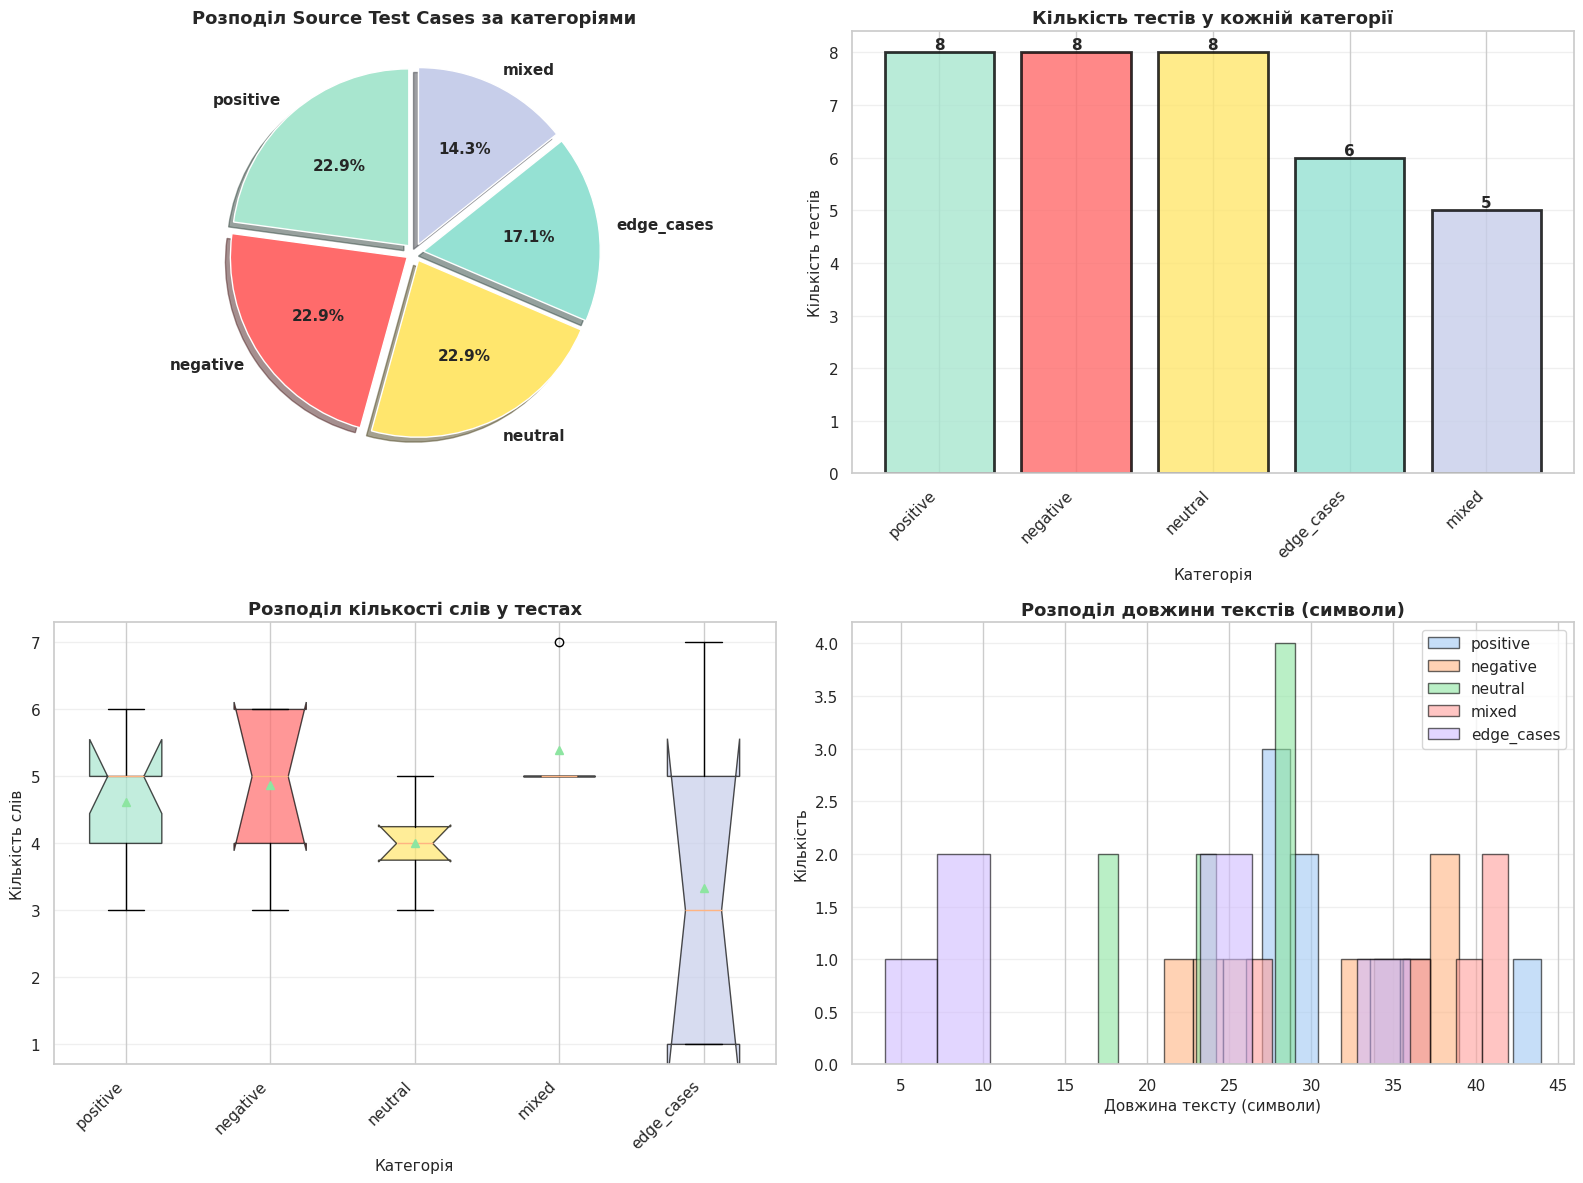


### Крок 2: Запускаємо Source Test Cases через Analyzer ###

✅ Аналіз завершено!

### 📊 Результати аналізу Source Test Cases ###



,id,category,text,sentiment,confidence,positive_score,negative_score,total_words
0,STC_001,positive,This product is excellent and amazing,POSITIVE,0.95,2.0,0.0,6
1,STC_002,positive,I love this wonderful service,POSITIVE,0.95,2.0,0.0,5
2,STC_003,positive,"Great experience, highly recommend",POSITIVE,0.95,1.0,0.0,4
3,STC_004,positive,Absolutely fantastic quality,POSITIVE,0.95,1.5,0.0,3
4,STC_005,positive,Very happy with the results,POSITIVE,0.95,1.5,0.0,5
5,STC_006,positive,Outstanding performance and beautiful design,POSITIVE,0.95,2.0,0.0,5
6,STC_007,positive,Perfect solution for my needs,POSITIVE,0.95,1.0,0.0,5
7,STC_008,positive,Really enjoyed every moment,NEUTRAL,0.50,0.0,0.0,4
8,STC_009,negative,This is terrible and disappointing,NEGATIVE,0.95,0.0,2.0,5
9,STC_010,negative,I hate this awful product,NEGATIVE,0.95,0.0,2.0,5



... та ще 25 результатів


### 📊 Статистика результатів ###



,Категорія,Кількість тестів,Середня впевненість
0,Positive,8,0.894
1,Negative,8,0.950
2,Neutral,8,0.500
3,Mixed,5,0.500
4,Edge Cases,6,0.824



### 📊 Візуалізація 2: Результати аналізу Source Tests ###



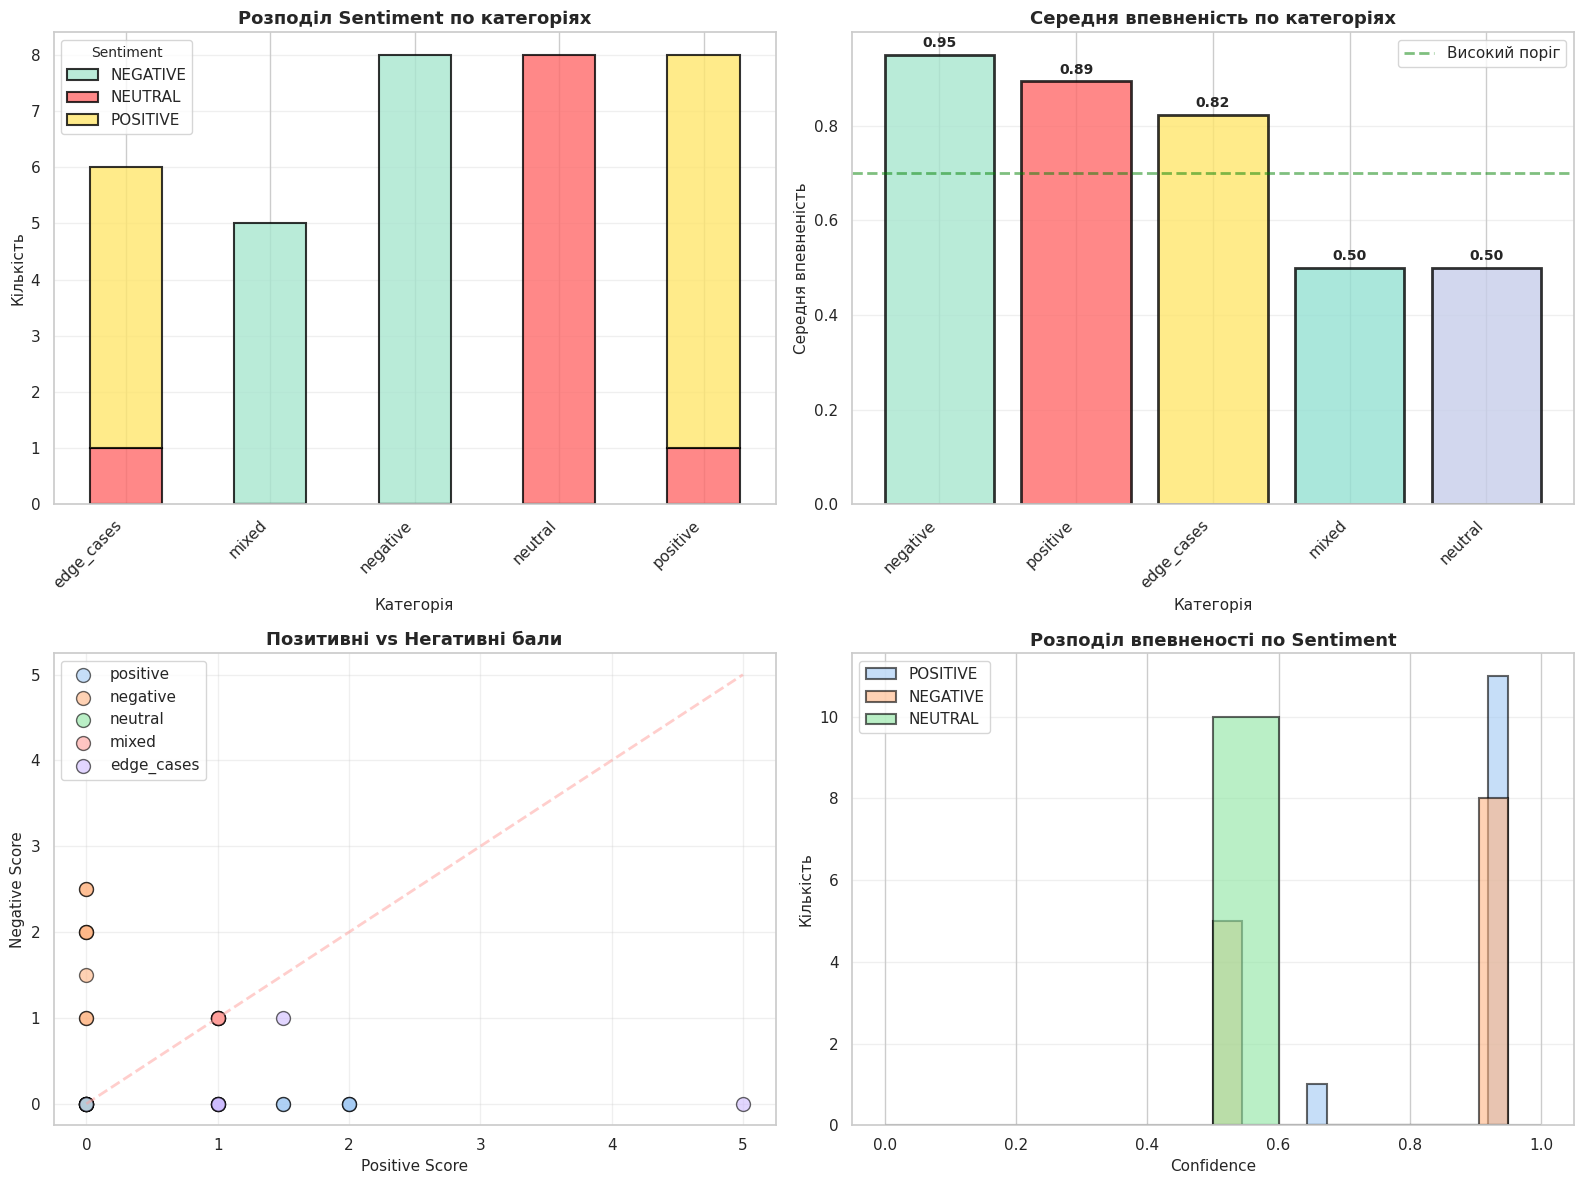


✅ Згенеровано та проаналізовано 35 Source Test Cases!
📝 Далі: Генерація Follow-up Test Cases за допомогою MR


In [ ]:
# @title
# ==============================================================================
# БЛОК 5: ГЕНЕРАЦІЯ SOURCE TEST CASES (ВИХІДНИХ ТЕСТОВИХ ВИПАДКІВ)
# ==============================================================================

print("\n" + "=" * 70)
print("📝 ГЕНЕРАЦІЯ SOURCE TEST CASES")
print("=" * 70)

source_intro = """
## 🎯 Що таке Source Test Cases?

**Source Test Cases** - це початкові тестові випадки, з яких ми будемо
генерувати follow-up тести, застосовуючи метаморфні відношення.

**Важливо:**
У метаморфному тестуванні Source TC **не обов'язково** мають відомий
правильний результат! Це одна з ключових переваг MT - ми можемо тестувати
без "oracle" (еталонної відповіді).

**Наша стратегія генерації:**
1. Створюємо різноманітні тексти з різною тональністю
2. Охоплюємо різні довжини та складність
3. Включаємо edge cases (граничні випадки)
4. Забезпечуємо баланс між позитивними, негативними та нейтральними текстами
"""

display(Markdown(source_intro))

print("\n### Крок 1: Створюємо набір Source Test Cases ###\n")

# Категорії Source Test Cases
source_test_cases = {
    'positive': [
        "This product is excellent and amazing",
        "I love this wonderful service",
        "Great experience, highly recommend",
        "Absolutely fantastic quality",
        "Very happy with the results",
        "Outstanding performance and beautiful design",
        "Perfect solution for my needs",
        "Really enjoyed every moment"
    ],
    'negative': [
        "This is terrible and disappointing",
        "I hate this awful product",
        "Worst experience ever",
        "Completely useless and waste of money",
        "Very poor quality and bad service",
        "Horrible design and frustrating to use",
        "Absolutely disappointed with everything",
        "Really bad and annoying"
    ],
    'neutral': [
        "This product exists and works",
        "I received the item yesterday",
        "The color is blue",
        "It has standard features",
        "Delivered on time",
        "Made of plastic material",
        "Contains instructions inside",
        "Available in different sizes"
    ],
    'mixed': [
        "Good quality but bad price",
        "Love the design but hate the functionality",
        "Great features however terrible support",
        "Excellent product with poor packaging",
        "Amazing look but disappointing performance"
    ],
    'edge_cases': [
        "good",  # одне слово
        "Not bad at all, really good actually",  # подвійне заперечення
        "AMAZING!!!",  # капс + знаки оклику
        "This is... okay, I guess",  # невизначеність
        "   good   ",  # пробіли
        "good good good good good"  # повторення
    ]
}

# Збираємо всі тести в один список
all_source_tests = []
for category, tests in source_test_cases.items():
    for test in tests:
        all_source_tests.append({
            'id': f'STC_{len(all_source_tests)+1:03d}',
            'category': category,
            'text': test
        })

df_source = pd.DataFrame(all_source_tests)

print(f"✅ Створено {len(all_source_tests)} Source Test Cases\n")

# Показуємо таблицю
print("### 📊 Таблиця Source Test Cases ###\n")
display(df_source.head(15))

print(f"\n... та ще {len(df_source) - 15} тестів\n")

# Статистика по категоріях
print("\n### 📊 Статистика Source Test Cases за категоріями ###\n")

category_stats = df_source['category'].value_counts().reset_index()
category_stats.columns = ['Категорія', 'Кількість']
display(category_stats)

# Візуалізація 1: Розподіл за категоріями
print("\n### 📊 Візуалізація 1: Розподіл Source Test Cases ###\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Графік 1: Pie chart розподілу
ax1 = axes[0, 0]
category_counts = df_source['category'].value_counts()
colors_cat = ['#A8E6CF', '#FF6B6B', '#FFE66D', '#95E1D3', '#C7CEEA']
explode = [0.05] * len(category_counts)

wedges, texts, autotexts = ax1.pie(category_counts.values,
                                     labels=category_counts.index,
                                     colors=colors_cat[:len(category_counts)],
                                     autopct='%1.1f%%',
                                     startangle=90,
                                     explode=explode,
                                     textprops={'fontsize': 11, 'weight': 'bold'},
                                     shadow=True)
ax1.set_title('Розподіл Source Test Cases за категоріями', fontsize=13, weight='bold')

# Графік 2: Bar chart кількості по категоріях
ax2 = axes[0, 1]
bars = ax2.bar(category_counts.index, category_counts.values,
               color=colors_cat[:len(category_counts)],
               alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_title('Кількість тестів у кожній категорії', fontsize=13, weight='bold')
ax2.set_ylabel('Кількість тестів', fontsize=11)
ax2.set_xlabel('Категорія', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, weight='bold')

# Графік 3: Довжина текстів
ax3 = axes[1, 0]
df_source['text_length'] = df_source['text'].apply(len)
df_source['word_count'] = df_source['text'].apply(lambda x: len(x.split()))

categories_for_box = df_source['category'].unique()
box_data = [df_source[df_source['category'] == cat]['word_count'].values
            for cat in categories_for_box]

bp = ax3.boxplot(box_data, labels=categories_for_box, patch_artist=True,
                 notch=True, showmeans=True)

# Розфарбовуємо boxplot
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_title('Розподіл кількості слів у тестах', fontsize=13, weight='bold')
ax3.set_ylabel('Кількість слів', fontsize=11)
ax3.set_xlabel('Категорія', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Графік 4: Histogram довжини символів
ax4 = axes[1, 1]
for category in categories_for_box:
    cat_data = df_source[df_source['category'] == category]['text_length']
    ax4.hist(cat_data, alpha=0.6, label=category, bins=10, edgecolor='black')

ax4.set_title('Розподіл довжини текстів (символи)', fontsize=13, weight='bold')
ax4.set_xlabel('Довжина тексту (символи)', fontsize=11)
ax4.set_ylabel('Кількість', fontsize=11)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n### Крок 2: Запускаємо Source Test Cases через Analyzer ###\n")

# Аналізуємо всі source тести
source_results = []
for idx, row in df_source.iterrows():
    result = analyzer.analyze(row['text'])
    result['id'] = row['id']
    result['category'] = row['category']
    source_results.append(result)

df_source_results = pd.DataFrame(source_results)

# Перегруповуємо колонки для зручності
df_source_results = df_source_results[['id', 'category', 'text', 'sentiment',
                                        'confidence', 'positive_score',
                                        'negative_score', 'total_words']]

print("✅ Аналіз завершено!\n")

# Показуємо результати
print("### 📊 Результати аналізу Source Test Cases ###\n")
display(df_source_results.head(10))
print(f"\n... та ще {len(df_source_results) - 10} результатів\n")

# Статистика результатів
print("\n### 📊 Статистика результатів ###\n")

stats_summary = pd.DataFrame({
    'Категорія': ['Positive', 'Negative', 'Neutral', 'Mixed', 'Edge Cases'],
    'Кількість тестів': [
        len(df_source_results[df_source_results['category'] == 'positive']),
        len(df_source_results[df_source_results['category'] == 'negative']),
        len(df_source_results[df_source_results['category'] == 'neutral']),
        len(df_source_results[df_source_results['category'] == 'mixed']),
        len(df_source_results[df_source_results['category'] == 'edge_cases'])
    ],
    'Середня впевненість': [
        df_source_results[df_source_results['category'] == 'positive']['confidence'].mean(),
        df_source_results[df_source_results['category'] == 'negative']['confidence'].mean(),
        df_source_results[df_source_results['category'] == 'neutral']['confidence'].mean(),
        df_source_results[df_source_results['category'] == 'mixed']['confidence'].mean(),
        df_source_results[df_source_results['category'] == 'edge_cases']['confidence'].mean()
    ]
})

display(stats_summary.style.format({'Середня впевненість': '{:.3f}'}))

# Візуалізація 2: Результати аналізу
print("\n### 📊 Візуалізація 2: Результати аналізу Source Tests ###\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Графік 1: Sentiment distribution по категоріях
ax1 = axes[0, 0]
sentiment_by_cat = pd.crosstab(df_source_results['category'],
                                df_source_results['sentiment'])

sentiment_by_cat.plot(kind='bar', stacked=True, ax=ax1,
                      color=['#A8E6CF', '#FF6B6B', '#FFE66D'],
                      alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_title('Розподіл Sentiment по категоріях', fontsize=13, weight='bold')
ax1.set_ylabel('Кількість', fontsize=11)
ax1.set_xlabel('Категорія', fontsize=11)
ax1.legend(title='Sentiment', title_fontsize=10)
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Графік 2: Середня впевненість по категоріях
ax2 = axes[0, 1]
avg_conf_by_cat = df_source_results.groupby('category')['confidence'].mean().sort_values(ascending=False)
bars2 = ax2.bar(avg_conf_by_cat.index, avg_conf_by_cat.values,
                color=colors_cat[:len(avg_conf_by_cat)],
                alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_title('Середня впевненість по категоріях', fontsize=13, weight='bold')
ax2.set_ylabel('Середня впевненість', fontsize=11)
ax2.set_xlabel('Категорія', fontsize=11)
ax2.axhline(y=0.7, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Високий поріг')
ax2.grid(axis='y', alpha=0.3)
ax2.legend()
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10, weight='bold')

# Графік 3: Scatter plot - Positive vs Negative scores
ax3 = axes[1, 0]
for category in df_source_results['category'].unique():
    cat_data = df_source_results[df_source_results['category'] == category]
    ax3.scatter(cat_data['positive_score'], cat_data['negative_score'],
                label=category, alpha=0.6, s=100, edgecolors='black', linewidth=1)

ax3.set_title('Позитивні vs Негативні бали', fontsize=13, weight='bold')
ax3.set_xlabel('Positive Score', fontsize=11)
ax3.set_ylabel('Negative Score', fontsize=11)
ax3.legend()
ax3.grid(alpha=0.3)

# Діагональна лінія
max_val = max(df_source_results['positive_score'].max(),
              df_source_results['negative_score'].max())
ax3.plot([0, max_val], [0, max_val], 'r--', linewidth=2, alpha=0.5, label='Рівновага')

# Графік 4: Confidence distribution
ax4 = axes[1, 1]
for sent in ['POSITIVE', 'NEGATIVE', 'NEUTRAL']:
    sent_data = df_source_results[df_source_results['sentiment'] == sent]['confidence']
    if len(sent_data) > 0:
        ax4.hist(sent_data, alpha=0.6, bins=10,
                label=sent, edgecolor='black', linewidth=1.5)

ax4.set_title('Розподіл впевненості по Sentiment', fontsize=13, weight='bold')
ax4.set_xlabel('Confidence', fontsize=11)
ax4.set_ylabel('Кількість', fontsize=11)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print(f"✅ Згенеровано та проаналізовано {len(df_source_results)} Source Test Cases!")
print("📝 Далі: Генерація Follow-up Test Cases за допомогою MR")
print("=" * 70)


🔄 ГЕНЕРАЦІЯ FOLLOW-UP TEST CASES



## 🎯 Що таке Follow-up Test Cases?

**Follow-up Test Cases** - це тестові випадки, згенеровані з Source TC
шляхом застосування метаморфних відношень (MR).

**Процес:**
1. Беремо Source Test Case
2. Застосовуємо трансформацію з MR
3. Отримуємо Follow-up Test Case
4. Пара (Source, Follow-up) використовується для перевірки MR

**У цьому блоці:**
Ми створимо функції-трансформатори для кожного з 6 MR та згенеруємо
follow-up тести для всіх source тестів.



### Крок 1: Створюємо функції-трансформатори для кожного MR ###

✅ MR1: Case Invariance - створено
✅ MR2: Punctuation Invariance - створено
✅ MR3: Whitespace Invariance - створено
✅ MR4: Negation Change - створено
✅ MR5: Intensifier Addition - створено
✅ MR6: Sentiment Word Addition - створено


### Крок 2: Генеруємо Follow-up Test Cases для всіх Source тестів ###

✅ Згенеровано 560 Follow-up Test Cases!

### 📊 Статистика Follow-up тестів по MR ###



,MR,Кількість Follow-up тестів
0,MR1_Case,105
1,MR2_Punctuation,105
2,MR3_Whitespace,105
3,MR5_Intensifier,105
4,MR4_Negation,70
5,MR6_SentimentWord,70



### 📝 Приклади згенерованих Follow-up тестів ###


🔹 MR1_Case

Source:    'This product is excellent and amazing'
Follow-up: 'THIS PRODUCT IS EXCELLENT AND AMAZING'
ID:        STC_001_MR1_Case_FU1

Source:    'This product is excellent and amazing'
Follow-up: 'this product is excellent and amazing'
ID:        STC_001_MR1_Case_FU2

🔹 MR2_Punctuation

Source:    'This product is excellent and amazing'
Follow-up: 'This product is excellent and amazing!'
ID:        STC_001_MR2_Punctuation_FU1

Source:    'This product is excellent and amazing'
Follow-up: 'This product is excellent and amazing!!!'
ID:        STC_001_MR2_Punctuation_FU2

🔹 MR3_Whitespace

Source:    'This product is excellent and amazing'
Follow-up: 'This  product  is  excellent  and  amazing'
ID:        STC_001_MR3_Whitespace_FU1

Source:    'This product is excellent and amazing'
Follow-up: '  This product is excellent and amazing  '
ID:        STC_001_MR3_Whitespace_FU2

🔹 MR4_Negation

Source:    'This product is excell

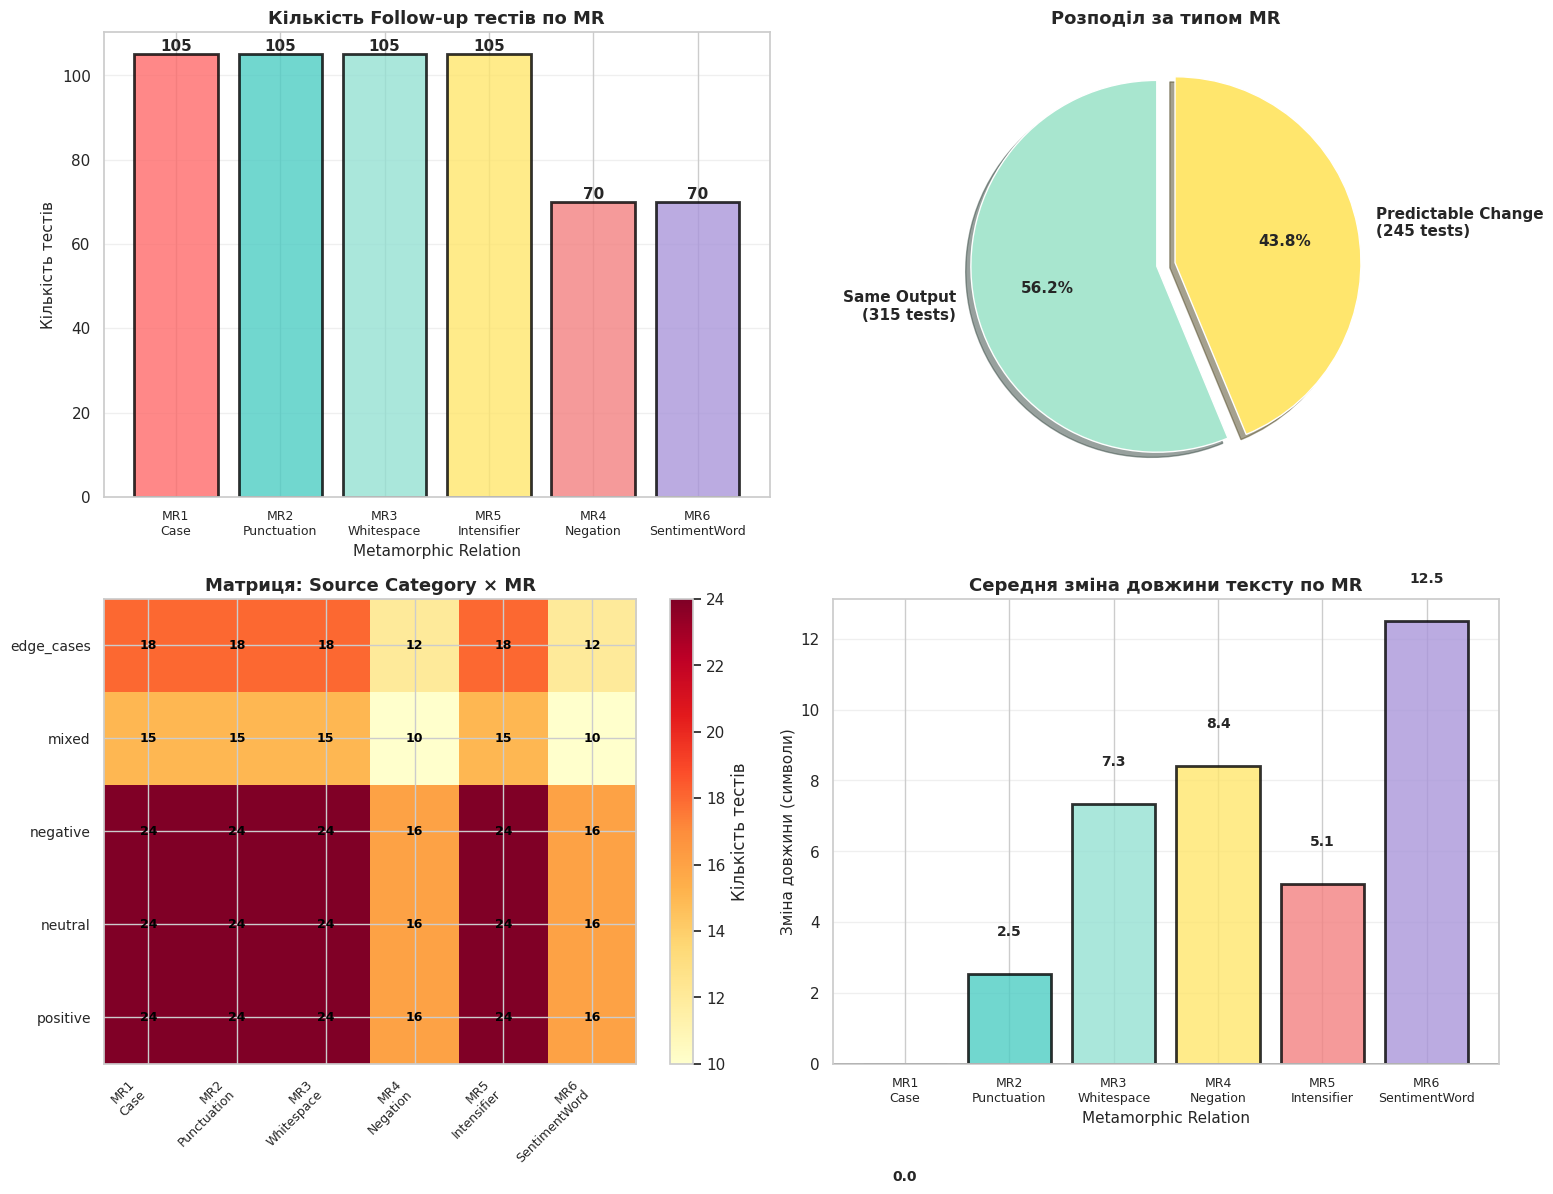


✅ Follow-up Test Cases згенеровано успішно!
📊 Загалом: 560 follow-up тестів з 35 source тестів
📝 Далі: Виконання Follow-up тестів та перевірка MR


In [ ]:
# @title
# ==============================================================================
# БЛОК 6: ГЕНЕРАЦІЯ FOLLOW-UP TEST CASES ЗА ДОПОМОГОЮ MR
# ==============================================================================

print("\n" + "=" * 70)
print("🔄 ГЕНЕРАЦІЯ FOLLOW-UP TEST CASES")
print("=" * 70)

followup_intro = """
## 🎯 Що таке Follow-up Test Cases?

**Follow-up Test Cases** - це тестові випадки, згенеровані з Source TC
шляхом застосування метаморфних відношень (MR).

**Процес:**
1. Беремо Source Test Case
2. Застосовуємо трансформацію з MR
3. Отримуємо Follow-up Test Case
4. Пара (Source, Follow-up) використовується для перевірки MR

**У цьому блоці:**
Ми створимо функції-трансформатори для кожного з 6 MR та згенеруємо
follow-up тести для всіх source тестів.
"""

display(Markdown(followup_intro))

print("\n### Крок 1: Створюємо функції-трансформатори для кожного MR ###\n")

# =============================================================================
# MR1: Case Invariance
# =============================================================================

def mr1_case_invariance(text: str) -> List[str]:
    """
    MR1: Case Invariance - Зміна регістру

    Трансформації:
    - UPPER CASE
    - lower case
    - Title Case
    """
    return [
        text.upper(),
        text.lower(),
        text.title()
    ]

print("✅ MR1: Case Invariance - створено")

# =============================================================================
# MR2: Punctuation Invariance
# =============================================================================

def mr2_punctuation_invariance(text: str) -> List[str]:
    """
    MR2: Punctuation Invariance - Додавання пунктуації

    Трансформації:
    - Додавання !
    - Додавання !!!
    - Додавання ком
    """
    return [
        text + "!",
        text + "!!!",
        text.replace(" ", ", ")
    ]

print("✅ MR2: Punctuation Invariance - створено")

# =============================================================================
# MR3: Whitespace Invariance
# =============================================================================

def mr3_whitespace_invariance(text: str) -> List[str]:
    """
    MR3: Whitespace Invariance - Додавання пробілів

    Трансформації:
    - Подвійні пробіли між словами
    - Пробіли на початку/кінці
    - Багато пробілів
    """
    return [
        text.replace(" ", "  "),  # подвійні пробіли
        "  " + text + "  ",  # пробіли на початку/кінці
        text.replace(" ", "     ")  # багато пробілів
    ]

print("✅ MR3: Whitespace Invariance - створено")

# =============================================================================
# MR4: Negation Change
# =============================================================================

def mr4_negation_change(text: str) -> List[str]:
    """
    MR4: Negation Change - Додавання заперечення

    Трансформації:
    - Додавання "not" перед першим sentiment словом
    - Додавання "never"
    - Заміна is/was на is not/was not
    """
    followups = []

    # Варіант 1: Додавання "not" перед дієсловом
    words = text.split()
    for i, word in enumerate(words):
        if word.lower() in ['is', 'was', 'are', 'were']:
            new_words = words[:i+1] + ['not'] + words[i+1:]
            followups.append(' '.join(new_words))
            break

    # Якщо не знайшли дієслово, додаємо "not" на початок
    if not followups:
        followups.append("not " + text)

    # Варіант 2: Заміна початку на заперечну форму
    if text.lower().startswith("this is"):
        followups.append(text.replace("This is", "This is not", 1).replace("this is", "this is not", 1))
    elif text.lower().startswith("i "):
        followups.append("I do not " + text[2:])
    else:
        followups.append("I never think " + text.lower())

    return followups[:2]  # повертаємо максимум 2 варіанти

print("✅ MR4: Negation Change - створено")

# =============================================================================
# MR5: Intensifier Addition
# =============================================================================

def mr5_intensifier_addition(text: str) -> List[str]:
    """
    MR5: Intensifier Addition - Додавання підсилювачів

    Трансформації:
    - Додавання "very" перед sentiment словами
    - Додавання "really"
    - Додавання "extremely"
    """
    intensifiers = ['very', 'really', 'extremely']
    followups = []

    # Sentiment слова для пошуку
    sentiment_words = analyzer.positive_words.union(analyzer.negative_words)

    words = text.split()

    for intensifier in intensifiers:
        new_words = words.copy()
        # Знаходимо перше sentiment слово і додаємо інтенсифікатор перед ним
        for i, word in enumerate(words):
            clean_word = ''.join(c for c in word.lower() if c.isalnum())
            if clean_word in sentiment_words:
                new_words.insert(i, intensifier)
                break
        followups.append(' '.join(new_words))

    return followups

print("✅ MR5: Intensifier Addition - створено")

# =============================================================================
# MR6: Sentiment Word Addition
# =============================================================================

def mr6_sentiment_word_addition(text: str) -> List[str]:
    """
    MR6: Sentiment Word Addition - Додавання sentiment слів

    Трансформації:
    - Додавання ще одного позитивного слова
    - Додавання ще одного негативного слова
    - Додавання синоніму
    """
    followups = []

    # Визначаємо тональність оригіналу
    result = analyzer.analyze(text)

    if result['sentiment'] == 'POSITIVE':
        # Додаємо позитивні слова
        followups.append(text + " and excellent")
        followups.append(text + " and wonderful")
    elif result['sentiment'] == 'NEGATIVE':
        # Додаємо негативні слова
        followups.append(text + " and terrible")
        followups.append(text + " and awful")
    else:
        # Для нейтральних додаємо нейтральні уточнення
        followups.append(text + " and normal")
        followups.append(text + " and standard")

    return followups

print("✅ MR6: Sentiment Word Addition - створено")

print("\n" + "=" * 70)

# =============================================================================
# Збираємо всі MR в словник
# =============================================================================

mr_transformers = {
    'MR1_Case': mr1_case_invariance,
    'MR2_Punctuation': mr2_punctuation_invariance,
    'MR3_Whitespace': mr3_whitespace_invariance,
    'MR4_Negation': mr4_negation_change,
    'MR5_Intensifier': mr5_intensifier_addition,
    'MR6_SentimentWord': mr6_sentiment_word_addition
}

print("\n### Крок 2: Генеруємо Follow-up Test Cases для всіх Source тестів ###\n")

# Генеруємо follow-up тести
all_followup_tests = []

for idx, source_row in df_source_results.iterrows():
    source_id = source_row['id']
    source_text = source_row['text']

    # Застосовуємо кожен MR
    for mr_name, mr_func in mr_transformers.items():
        try:
            followup_texts = mr_func(source_text)

            for i, fu_text in enumerate(followup_texts):
                all_followup_tests.append({
                    'source_id': source_id,
                    'source_text': source_text,
                    'mr_name': mr_name,
                    'followup_id': f'{source_id}_{mr_name}_FU{i+1}',
                    'followup_text': fu_text
                })
        except Exception as e:
            print(f"⚠️ Помилка при застосуванні {mr_name} до {source_id}: {e}")

df_followup = pd.DataFrame(all_followup_tests)

print(f"✅ Згенеровано {len(df_followup)} Follow-up Test Cases!\n")

# Статистика по MR
print("### 📊 Статистика Follow-up тестів по MR ###\n")

mr_stats = df_followup['mr_name'].value_counts().reset_index()
mr_stats.columns = ['MR', 'Кількість Follow-up тестів']
display(mr_stats)

# Показуємо приклади
print("\n### 📝 Приклади згенерованих Follow-up тестів ###\n")

# Показуємо по одному прикладу для кожного MR
for mr_name in mr_transformers.keys():
    print(f"\n{'='*70}")
    print(f"🔹 {mr_name}")
    print('='*70)

    examples = df_followup[df_followup['mr_name'] == mr_name].head(2)

    for idx, row in examples.iterrows():
        print(f"\nSource:    '{row['source_text']}'")
        print(f"Follow-up: '{row['followup_text']}'")
        print(f"ID:        {row['followup_id']}")

print("\n" + "=" * 70)

# Візуалізація генерації
print("\n### 📊 Візуалізація: Розподіл Follow-up тестів ###\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Графік 1: Кількість follow-up тестів по MR
ax1 = axes[0, 0]
mr_counts = df_followup['mr_name'].value_counts()
colors_mr = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D', '#F38181', '#AA96DA']

bars1 = ax1.bar(range(len(mr_counts)), mr_counts.values,
                color=colors_mr, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_title('Кількість Follow-up тестів по MR', fontsize=13, weight='bold')
ax1.set_ylabel('Кількість тестів', fontsize=11)
ax1.set_xlabel('Metamorphic Relation', fontsize=11)
ax1.set_xticks(range(len(mr_counts)))
ax1.set_xticklabels([mr.replace('_', '\n') for mr in mr_counts.index], fontsize=9)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, weight='bold')

# Графік 2: Pie chart типів MR
ax2 = axes[0, 1]
mr_types = {
    'Same Output': ['MR1_Case', 'MR2_Punctuation', 'MR3_Whitespace'],
    'Predictable Change': ['MR4_Negation', 'MR5_Intensifier', 'MR6_SentimentWord']
}

type_counts = []
type_labels = []
for mr_type, mr_list in mr_types.items():
    count = df_followup[df_followup['mr_name'].isin(mr_list)].shape[0]
    type_counts.append(count)
    type_labels.append(f'{mr_type}\n({count} tests)')

colors_type = ['#A8E6CF', '#FFE66D']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax2.pie(type_counts, labels=type_labels,
                                     colors=colors_type, autopct='%1.1f%%',
                                     startangle=90, explode=explode,
                                     textprops={'fontsize': 11, 'weight': 'bold'},
                                     shadow=True)
ax2.set_title('Розподіл за типом MR', fontsize=13, weight='bold')

# Графік 3: Матриця Source vs MR
ax3 = axes[1, 0]

# Створюємо матрицю: скільки follow-up тестів для кожної комбінації source category і MR
source_categories = df_source_results.set_index('id')['category'].to_dict()
df_followup['source_category'] = df_followup['source_id'].map(source_categories)

matrix_data = pd.crosstab(df_followup['source_category'], df_followup['mr_name'])

im = ax3.imshow(matrix_data.values, cmap='YlOrRd', aspect='auto')
ax3.set_xticks(range(len(matrix_data.columns)))
ax3.set_yticks(range(len(matrix_data.index)))
ax3.set_xticklabels([col.replace('_', '\n') for col in matrix_data.columns],
                     fontsize=9, rotation=45, ha='right')
ax3.set_yticklabels(matrix_data.index, fontsize=10)
ax3.set_title('Матриця: Source Category × MR', fontsize=13, weight='bold')

# Додаємо значення в клітинки
for i in range(len(matrix_data.index)):
    for j in range(len(matrix_data.columns)):
        text = ax3.text(j, i, matrix_data.values[i, j],
                       ha="center", va="center", color="black", fontsize=9, weight='bold')

plt.colorbar(im, ax=ax3, label='Кількість тестів')

# Графік 4: Довжина follow-up тестів порівняно з source
ax4 = axes[1, 1]

df_followup['followup_length'] = df_followup['followup_text'].apply(len)
df_followup['source_length'] = df_followup['source_text'].apply(len)
df_followup['length_diff'] = df_followup['followup_length'] - df_followup['source_length']

length_by_mr = df_followup.groupby('mr_name')['length_diff'].mean()

bars4 = ax4.bar(range(len(length_by_mr)), length_by_mr.values,
                color=colors_mr, alpha=0.8, edgecolor='black', linewidth=2)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax4.set_title('Середня зміна довжини тексту по MR', fontsize=13, weight='bold')
ax4.set_ylabel('Зміна довжини (символи)', fontsize=11)
ax4.set_xlabel('Metamorphic Relation', fontsize=11)
ax4.set_xticks(range(len(length_by_mr)))
ax4.set_xticklabels([mr.replace('_', '\n') for mr in length_by_mr.index], fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# Підписуємо значення
for bar in bars4:
    height = bar.get_height()
    label_y = height + 1 if height > 0 else height - 3
    ax4.text(bar.get_x() + bar.get_width()/2., label_y,
             f'{height:.1f}', ha='center', va='bottom' if height > 0 else 'top',
             fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print(f"✅ Follow-up Test Cases згенеровано успішно!")
print(f"📊 Загалом: {len(df_followup)} follow-up тестів з {len(df_source_results)} source тестів")
print("📝 Далі: Виконання Follow-up тестів та перевірка MR")
print("=" * 70)

In [ ]:
# @title
# ==============================================================================
# БЛОК 7: ВИКОНАННЯ FOLLOW-UP ТЕСТІВ ТА ПЕРЕВІРКА MR
# ==============================================================================

print("\n" + "=" * 70)
print("🧪 ВИКОНАННЯ FOLLOW-UP ТЕСТІВ ТА ПЕРЕВІРКА MR")
print("=" * 70)

execution_intro = """
## 🎯 Що робимо в цьому блоці?

Тепер ми:
1. **Виконуємо всі Follow-up тести** через наш Sentiment Analyzer
2. **Порівнюємо результати** Source та Follow-up тестів
3. **Перевіряємо кожне MR** - чи виконується метаморфне відношення?
4. **Виявляємо порушення** - де система не відповідає очікуванням
5. **Аналізуємо результати** - які MR працюють, а які ні

**Критерії перевірки для кожного типу MR:**

### Same Output MR (MR1, MR2, MR3):
- ✅ PASS: `sentiment(source) == sentiment(follow-up)`
- ❌ FAIL: `sentiment(source) != sentiment(follow-up)`

### Predictable Change MR:
- **MR4 (Negation)**: Sentiment повинен інвертуватися
  - ✅ PASS: POSITIVE → NEGATIVE або NEGATIVE → POSITIVE
  - ❌ FAIL: Sentiment не змінився або став NEUTRAL

- **MR5 (Intensifier)**: Confidence повинна зрости
  - ✅ PASS: `confidence(follow-up) > confidence(source)`
  - ❌ FAIL: Confidence зменшилась або не змінилась

- **MR6 (Sentiment Word)**: Score повинен зрости
  - ✅ PASS: `score(follow-up) > score(source)` при тому ж sentiment
  - ❌ FAIL: Score зменшився або не змінився
"""

display(Markdown(execution_intro))

print("\n### Крок 1: Виконуємо всі Follow-up тести ###\n")

# Аналізуємо всі follow-up тести
print("⏳ Аналіз follow-up тестів... (це може зайняти деякий час)\n")

followup_results = []

for idx, row in df_followup.iterrows():
    result = analyzer.analyze(row['followup_text'])
    result['followup_id'] = row['followup_id']
    result['source_id'] = row['source_id']
    result['mr_name'] = row['mr_name']
    result['source_text'] = row['source_text']
    result['followup_text'] = row['followup_text']
    followup_results.append(result)

    # Прогрес
    if (idx + 1) % 50 == 0:
        print(f"  Оброблено {idx + 1}/{len(df_followup)} тестів...")

df_followup_results = pd.DataFrame(followup_results)

# Перегруповуємо колонки
df_followup_results = df_followup_results[['followup_id', 'source_id', 'mr_name',
                                            'source_text', 'followup_text',
                                            'sentiment', 'confidence',
                                            'positive_score', 'negative_score',
                                            'total_words']]

print(f"\n✅ Проаналізовано {len(df_followup_results)} follow-up тестів!\n")

# Показуємо приклади результатів
print("### 📊 Приклади результатів Follow-up тестів ###\n")
display(df_followup_results.head(10))

print("\n### Крок 2: Об'єднуємо Source та Follow-up результати ###\n")

# Об'єднуємо source результати
source_results_dict = df_source_results.set_index('id').to_dict('index')

# Додаємо source результати до follow-up
df_combined = df_followup_results.copy()
df_combined['source_sentiment'] = df_combined['source_id'].apply(
    lambda x: source_results_dict[x]['sentiment']
)
df_combined['source_confidence'] = df_combined['source_id'].apply(
    lambda x: source_results_dict[x]['confidence']
)
df_combined['source_positive_score'] = df_combined['source_id'].apply(
    lambda x: source_results_dict[x]['positive_score']
)
df_combined['source_negative_score'] = df_combined['source_id'].apply(
    lambda x: source_results_dict[x]['negative_score']
)

# Перейменовуємо для ясності
df_combined = df_combined.rename(columns={
    'sentiment': 'followup_sentiment',
    'confidence': 'followup_confidence',
    'positive_score': 'followup_positive_score',
    'negative_score': 'followup_negative_score'
})

print("✅ Дані об'єднано!\n")

print("\n### Крок 3: Перевіряємо виконання MR ###\n")

# Функція перевірки MR
def check_mr_satisfaction(row):
    """
    Перевіряє, чи виконується метаморфне відношення для даної пари тестів.
    """
    mr_name = row['mr_name']

    # MR1, MR2, MR3: Same Output
    if mr_name in ['MR1_Case', 'MR2_Punctuation', 'MR3_Whitespace']:
        # Sentiment повинен залишитися таким самим
        passed = row['source_sentiment'] == row['followup_sentiment']
        reason = "Sentiment matches" if passed else f"Sentiment changed: {row['source_sentiment']} → {row['followup_sentiment']}"
        return passed, reason

    # MR4: Negation Change
    elif mr_name == 'MR4_Negation':
        # Sentiment повинен інвертуватися
        source_sent = row['source_sentiment']
        followup_sent = row['followup_sentiment']

        # Ідеальний випадок: POSITIVE ↔ NEGATIVE
        if (source_sent == 'POSITIVE' and followup_sent == 'NEGATIVE') or \
           (source_sent == 'NEGATIVE' and followup_sent == 'POSITIVE'):
            return True, "Sentiment inverted correctly"

        # Прийнятно: якщо було NEUTRAL, може стати будь-яким
        if source_sent == 'NEUTRAL' and followup_sent != 'NEUTRAL':
            return True, "NEUTRAL became polarized"

        # Не пройшов: залишився таким самим або став NEUTRAL
        return False, f"Sentiment not inverted: {source_sent} → {followup_sent}"

    # MR5: Intensifier Addition
    elif mr_name == 'MR5_Intensifier':
        # Sentiment повинен залишитися, confidence зрости
        sentiment_same = row['source_sentiment'] == row['followup_sentiment']
        confidence_increased = row['followup_confidence'] > row['source_confidence']

        if sentiment_same and confidence_increased:
            return True, f"Confidence increased: {row['source_confidence']:.2f} → {row['followup_confidence']:.2f}"
        elif not sentiment_same:
            return False, f"Sentiment changed: {row['source_sentiment']} → {row['followup_sentiment']}"
        else:
            return False, f"Confidence not increased: {row['source_confidence']:.2f} → {row['followup_confidence']:.2f}"

    # MR6: Sentiment Word Addition
    elif mr_name == 'MR6_SentimentWord':
        # Sentiment повинен залишитися, score зрости
        sentiment_same = row['source_sentiment'] == row['followup_sentiment']

        # Рахуємо відповідний score
        if row['source_sentiment'] == 'POSITIVE':
            source_score = row['source_positive_score']
            followup_score = row['followup_positive_score']
        elif row['source_sentiment'] == 'NEGATIVE':
            source_score = row['source_negative_score']
            followup_score = row['followup_negative_score']
        else:
            # Для NEUTRAL можемо перевіряти загальну зміну
            source_score = row['source_positive_score'] + row['source_negative_score']
            followup_score = row['followup_positive_score'] + row['followup_negative_score']

        score_increased = followup_score > source_score

        if sentiment_same and score_increased:
            return True, f"Score increased: {source_score:.1f} → {followup_score:.1f}"
        elif not sentiment_same:
            return False, f"Sentiment changed: {row['source_sentiment']} → {row['followup_sentiment']}"
        else:
            return False, f"Score not increased: {source_score:.1f} → {followup_score:.1f}"

    return False, "Unknown MR"

# Застосовуємо перевірку до всіх тестів
print("⏳ Перевіряємо виконання MR для всіх тестів...\n")

mr_checks = df_combined.apply(check_mr_satisfaction, axis=1)
df_combined['mr_passed'] = mr_checks.apply(lambda x: x[0])
df_combined['mr_reason'] = mr_checks.apply(lambda x: x[1])

print("✅ Перевірка завершена!\n")

# Статистика проходження
print("### 📊 Статистика виконання MR ###\n")

overall_stats = pd.DataFrame({
    'Метрика': ['Всього тестів', 'Пройшли (PASS)', 'Не пройшли (FAIL)', 'Pass Rate (%)'],
    'Значення': [
        len(df_combined),
        df_combined['mr_passed'].sum(),
        (~df_combined['mr_passed']).sum(),
        f"{(df_combined['mr_passed'].sum() / len(df_combined) * 100):.2f}%"
    ]
})

display(overall_stats)

# Статистика по кожному MR
print("\n### 📊 Статистика по кожному MR ###\n")

mr_stats = df_combined.groupby('mr_name').agg({
    'mr_passed': ['count', 'sum', lambda x: f"{(x.sum()/len(x)*100):.1f}%"]
}).reset_index()

mr_stats.columns = ['MR', 'Всього тестів', 'Пройшли', 'Pass Rate']
mr_stats = mr_stats.sort_values('Pass Rate', ascending=False)

display(mr_stats)

# Показуємо приклади порушень
print("\n### ⚠️ Приклади порушень MR (FAILED тести) ###\n")

failed_tests = df_combined[~df_combined['mr_passed']].head(10)

if len(failed_tests) > 0:
    for idx, row in failed_tests.iterrows():
        print(f"\n{'='*70}")
        print(f"❌ FAILED: {row['mr_name']} - {row['followup_id']}")
        print(f"{'='*70}")
        print(f"Source:    '{row['source_text']}'")
        print(f"  → Sentiment: {row['source_sentiment']} (conf: {row['source_confidence']:.2f})")
        print(f"\nFollow-up: '{row['followup_text']}'")
        print(f"  → Sentiment: {row['followup_sentiment']} (conf: {row['followup_confidence']:.2f})")
        print(f"\nРезультат: {row['mr_reason']}")
else:
    print("🎉 Всі тести пройшли успішно! Порушень не виявлено.")

# Показуємо приклади успішних тестів
print("\n### ✅ Приклади успішних тестів (PASSED) ###\n")

passed_tests = df_combined[df_combined['mr_passed']].head(5)

for idx, row in passed_tests.iterrows():
    print(f"\n{'='*70}")
    print(f"✅ PASSED: {row['mr_name']} - {row['followup_id']}")
    print(f"{'='*70}")
    print(f"Source:    '{row['source_text']}'")
    print(f"  → Sentiment: {row['source_sentiment']} (conf: {row['source_confidence']:.2f})")
    print(f"\nFollow-up: '{row['followup_text']}'")
    print(f"  → Sentiment: {row['followup_sentiment']} (conf: {row['followup_confidence']:.2f})")
    print(f"\nРезультат: {row['mr_reason']}")

print("\n" + "=" * 70)
print("✅ Виконання та перевірка MR завершено!")
print("📊 Далі: Візуалізація та аналіз результатів")
print("=" * 70)


🧪 ВИКОНАННЯ FOLLOW-UP ТЕСТІВ ТА ПЕРЕВІРКА MR



## 🎯 Що робимо в цьому блоці?

Тепер ми:
1. **Виконуємо всі Follow-up тести** через наш Sentiment Analyzer
2. **Порівнюємо результати** Source та Follow-up тестів
3. **Перевіряємо кожне MR** - чи виконується метаморфне відношення?
4. **Виявляємо порушення** - де система не відповідає очікуванням
5. **Аналізуємо результати** - які MR працюють, а які ні

**Критерії перевірки для кожного типу MR:**

### Same Output MR (MR1, MR2, MR3):
- ✅ PASS: `sentiment(source) == sentiment(follow-up)`
- ❌ FAIL: `sentiment(source) != sentiment(follow-up)`

### Predictable Change MR:
- **MR4 (Negation)**: Sentiment повинен інвертуватися
  - ✅ PASS: POSITIVE → NEGATIVE або NEGATIVE → POSITIVE
  - ❌ FAIL: Sentiment не змінився або став NEUTRAL

- **MR5 (Intensifier)**: Confidence повинна зрости
  - ✅ PASS: `confidence(follow-up) > confidence(source)`
  - ❌ FAIL: Confidence зменшилась або не змінилась

- **MR6 (Sentiment Word)**: Score повинен зрости
  - ✅ PASS: `score(follow-up) > score(source)` при тому ж sentiment
  - ❌ FAIL: Score зменшився або не змінився



### Крок 1: Виконуємо всі Follow-up тести ###

⏳ Аналіз follow-up тестів... (це може зайняти деякий час)

  Оброблено 50/560 тестів...
  Оброблено 100/560 тестів...
  Оброблено 150/560 тестів...
  Оброблено 200/560 тестів...
  Оброблено 250/560 тестів...
  Оброблено 300/560 тестів...
  Оброблено 350/560 тестів...
  Оброблено 400/560 тестів...
  Оброблено 450/560 тестів...
  Оброблено 500/560 тестів...
  Оброблено 550/560 тестів...

✅ Проаналізовано 560 follow-up тестів!

### 📊 Приклади результатів Follow-up тестів ###



,followup_id,source_id,mr_name,source_text,followup_text,sentiment,confidence,positive_score,negative_score,total_words
0,STC_001_MR1_Case_FU1,STC_001,MR1_Case,This product is excellent and amazing,THIS PRODUCT IS EXCELLENT AND AMAZING,POSITIVE,0.95,2.0,0.0,6
1,STC_001_MR1_Case_FU2,STC_001,MR1_Case,This product is excellent and amazing,this product is excellent and amazing,POSITIVE,0.95,2.0,0.0,6
2,STC_001_MR1_Case_FU3,STC_001,MR1_Case,This product is excellent and amazing,This Product Is Excellent And Amazing,POSITIVE,0.95,2.0,0.0,6
3,STC_001_MR2_Punctuation_FU1,STC_001,MR2_Punctuation,This product is excellent and amazing,This product is excellent and amazing!,POSITIVE,0.95,2.0,0.0,6
4,STC_001_MR2_Punctuation_FU2,STC_001,MR2_Punctuation,This product is excellent and amazing,This product is excellent and amazing!!!,POSITIVE,0.95,2.0,0.0,6
5,STC_001_MR2_Punctuation_FU3,STC_001,MR2_Punctuation,This product is excellent and amazing,"This, product, is, excellent, and, amazing",POSITIVE,0.95,2.0,0.0,6
6,STC_001_MR3_Whitespace_FU1,STC_001,MR3_Whitespace,This product is excellent and amazing,This product is excellent and amazing,POSITIVE,0.95,2.0,0.0,6
7,STC_001_MR3_Whitespace_FU2,STC_001,MR3_Whitespace,This product is excellent and amazing,This product is excellent and amazing,POSITIVE,0.95,2.0,0.0,6
8,STC_001_MR3_Whitespace_FU3,STC_001,MR3_Whitespace,This product is excellent and amazing,This product is excellent and ...,POSITIVE,0.95,2.0,0.0,6
9,STC_001_MR4_Negation_FU1,STC_001,MR4_Negation,This product is excellent and amazing,This product is not excellent and amazing,POSITIVE,0.95,2.0,0.0,7



### Крок 2: Об'єднуємо Source та Follow-up результати ###

✅ Дані об'єднано!


### Крок 3: Перевіряємо виконання MR ###

⏳ Перевіряємо виконання MR для всіх тестів...

✅ Перевірка завершена!

### 📊 Статистика виконання MR ###



,Метрика,Значення
0,Всього тестів,560
1,Пройшли (PASS),365
2,Не пройшли (FAIL),195
3,Pass Rate (%),65.18%



### 📊 Статистика по кожному MR ###



,MR,Всього тестів,Пройшли,Pass Rate
5,MR6_SentimentWord,70,50,71.4%
0,MR1_Case,105,105,100.0%
1,MR2_Punctuation,105,105,100.0%
2,MR3_Whitespace,105,105,100.0%
3,MR4_Negation,70,0,0.0%
4,MR5_Intensifier,105,0,0.0%



### ⚠️ Приклади порушень MR (FAILED тести) ###


❌ FAILED: MR4_Negation - STC_001_MR4_Negation_FU1
Source:    'This product is excellent and amazing'
  → Sentiment: POSITIVE (conf: 0.95)

Follow-up: 'This product is not excellent and amazing'
  → Sentiment: POSITIVE (conf: 0.95)

Результат: Sentiment not inverted: POSITIVE → POSITIVE

❌ FAILED: MR4_Negation - STC_001_MR4_Negation_FU2
Source:    'This product is excellent and amazing'
  → Sentiment: POSITIVE (conf: 0.95)

Follow-up: 'I never think this product is excellent and amazing'
  → Sentiment: POSITIVE (conf: 0.95)

Результат: Sentiment not inverted: POSITIVE → POSITIVE

❌ FAILED: MR5_Intensifier - STC_001_MR5_Intensifier_FU1
Source:    'This product is excellent and amazing'
  → Sentiment: POSITIVE (conf: 0.95)

Follow-up: 'This product is very excellent and amazing'
  → Sentiment: POSITIVE (conf: 0.95)

Результат: Confidence not increased: 0.95 → 0.95

❌ FAILED: MR5_Intensifier - STC_001_MR5_Intensifier_FU2
Source:    'This pr


📊 ВІЗУАЛІЗАЦІЯ ТА АНАЛІЗ РЕЗУЛЬТАТІВ МЕТАМОРФНОГО ТЕСТУВАННЯ



## 🎯 Аналіз результатів

У цьому блоці ми детально проаналізуємо результати метаморфного тестування:
- Візуалізуємо pass/fail rate для кожного MR
- Проаналізуємо типи помилок
- Виявимо слабкі місця системи
- Зробимо висновки про якість Sentiment Analyzer



### 📊 Візуалізація 1: Загальна картина результатів ###



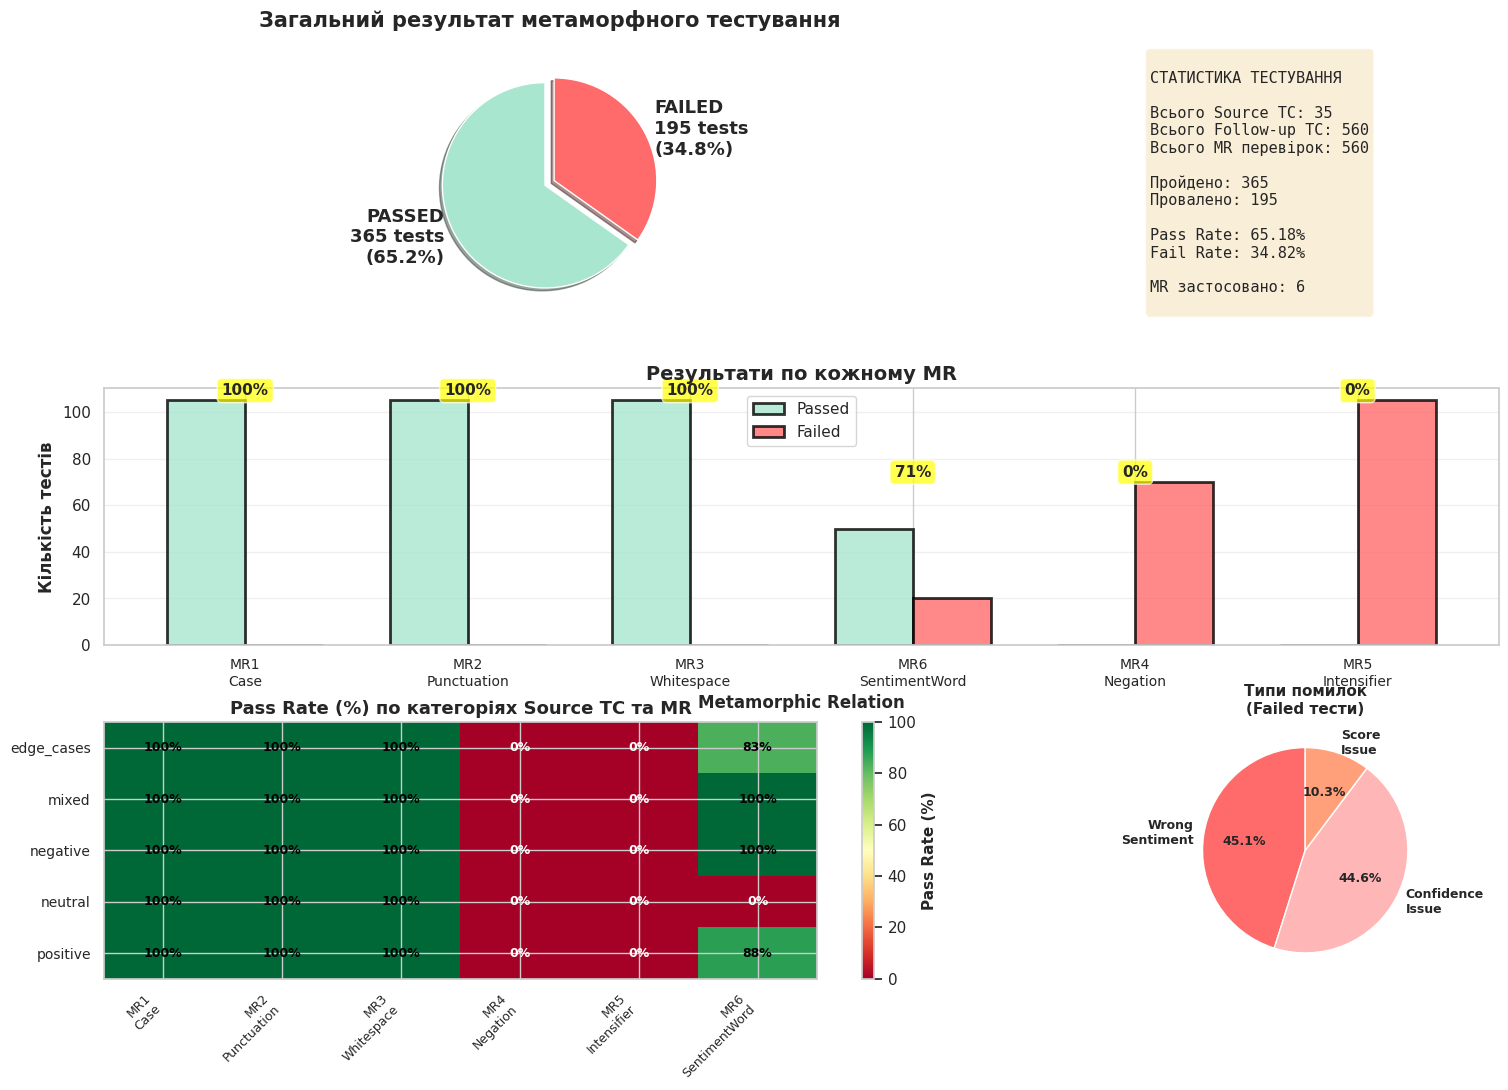


### 📊 Візуалізація 2: Детальний аналіз по типам MR ###



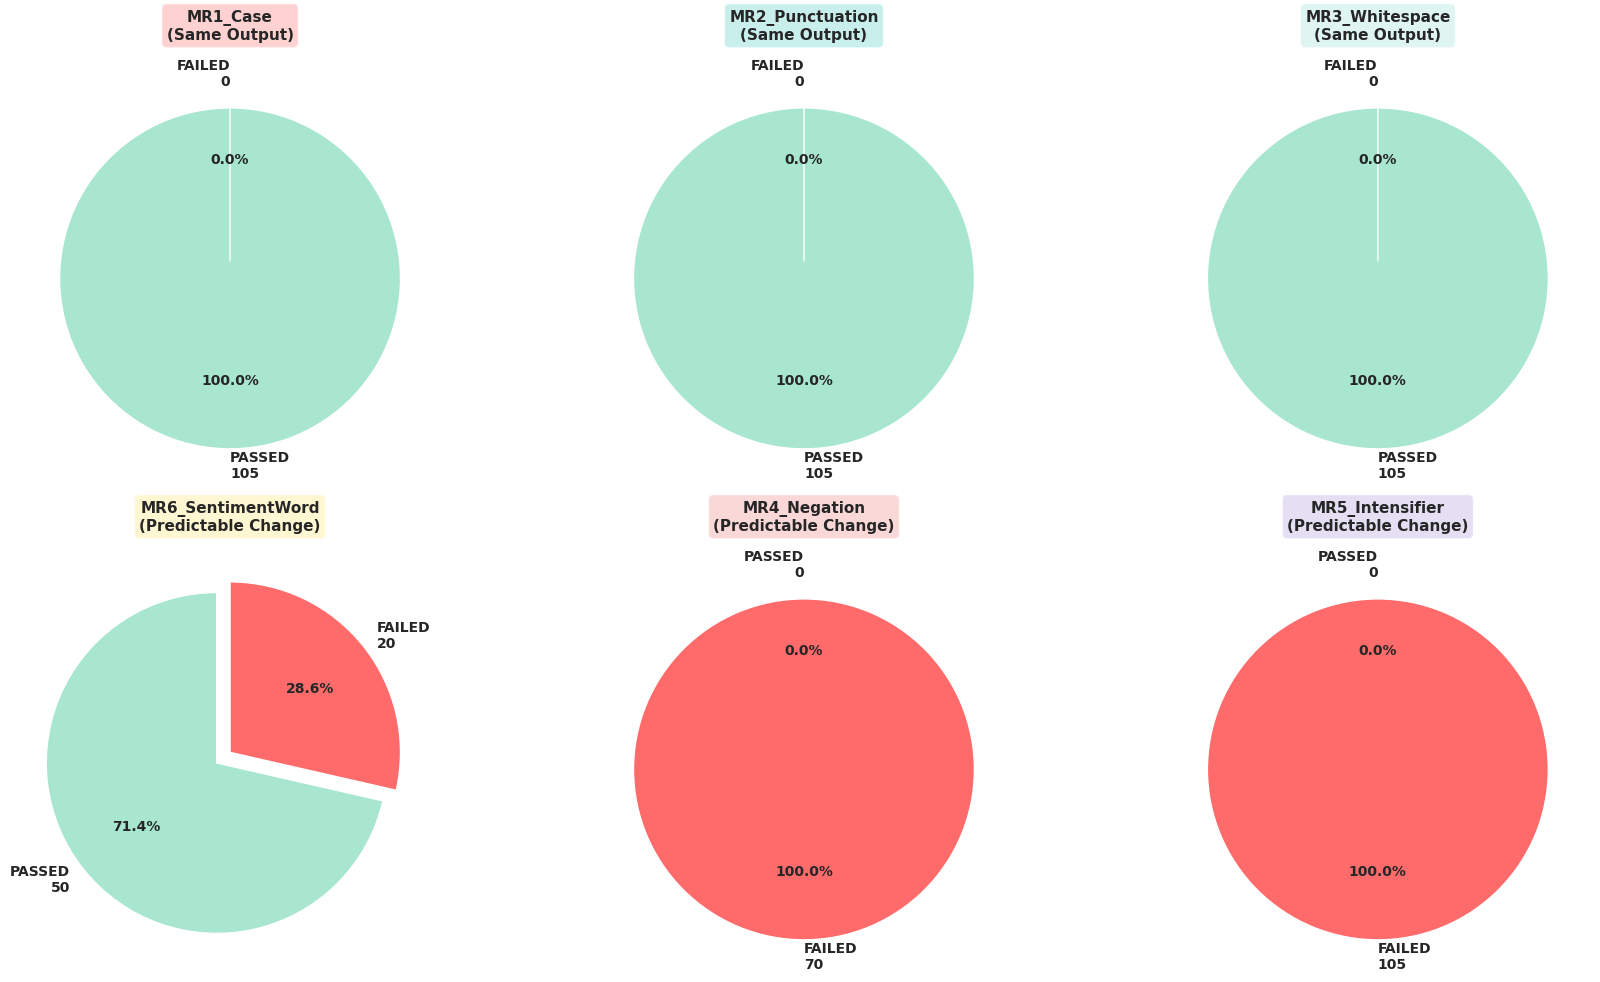


### 📊 Візуалізація 3: Аналіз змін Confidence та Scores ###



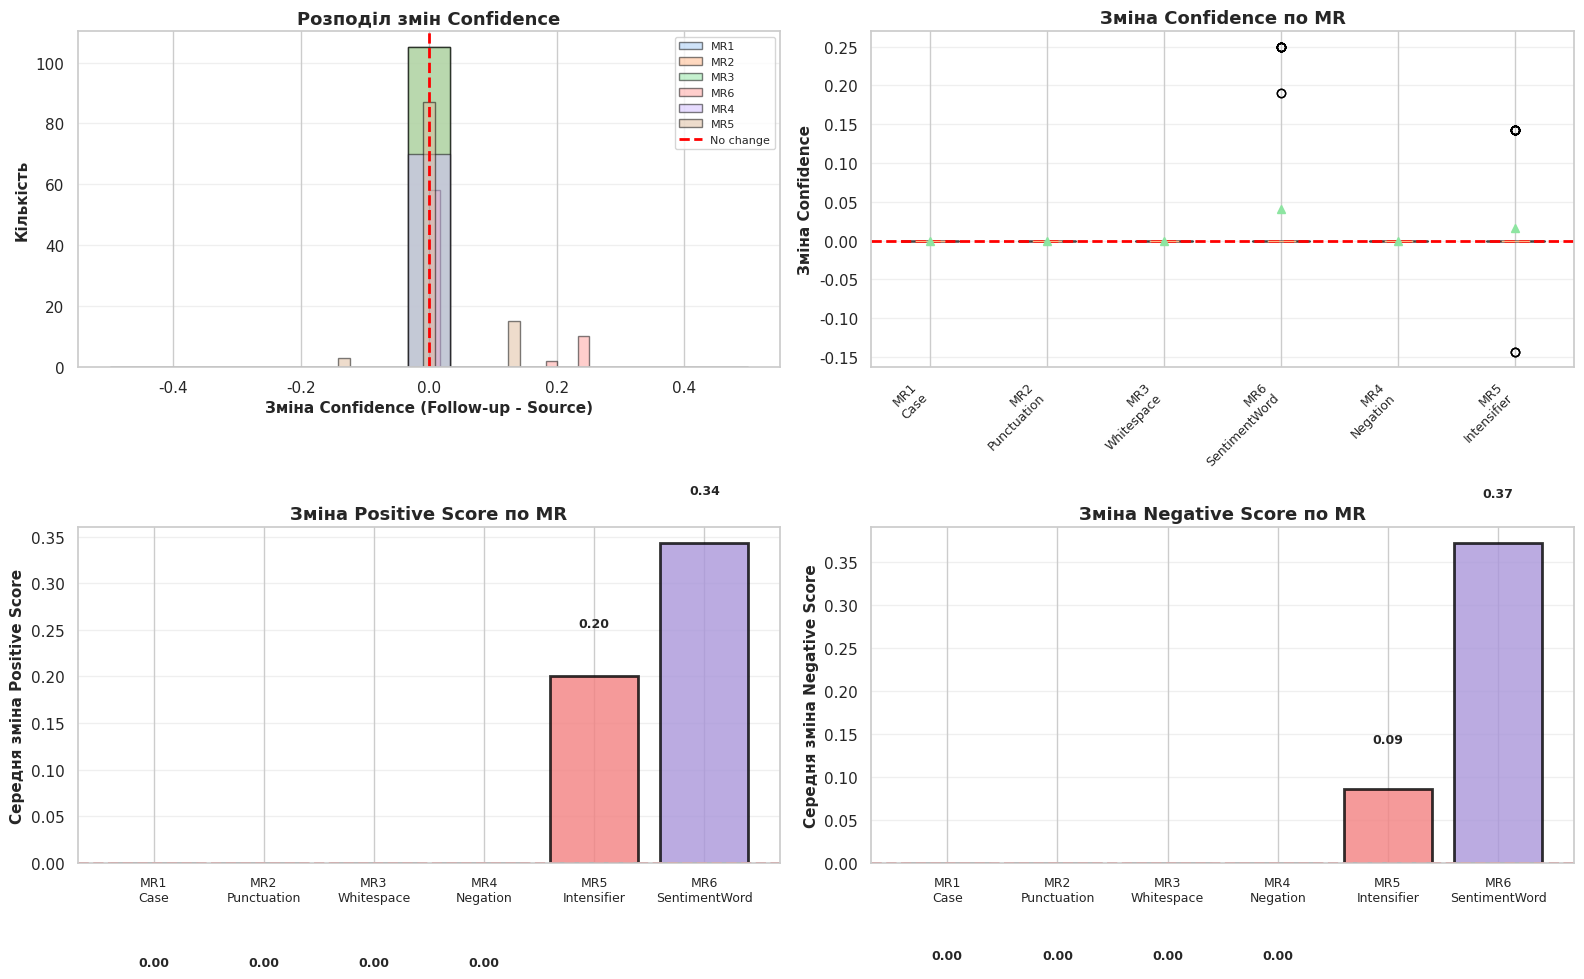


✅ Візуалізація та аналіз результатів завершено!
📝 Далі: Підсумки та висновки


In [ ]:
# @title
# ==============================================================================
# БЛОК 8: ВІЗУАЛІЗАЦІЯ ТА ДЕТАЛЬНИЙ АНАЛІЗ РЕЗУЛЬТАТІВ
# ==============================================================================

print("\n" + "=" * 70)
print("📊 ВІЗУАЛІЗАЦІЯ ТА АНАЛІЗ РЕЗУЛЬТАТІВ МЕТАМОРФНОГО ТЕСТУВАННЯ")
print("=" * 70)

analysis_intro = """
## 🎯 Аналіз результатів

У цьому блоці ми детально проаналізуємо результати метаморфного тестування:
- Візуалізуємо pass/fail rate для кожного MR
- Проаналізуємо типи помилок
- Виявимо слабкі місця системи
- Зробимо висновки про якість Sentiment Analyzer
"""

display(Markdown(analysis_intro))

print("\n### 📊 Візуалізація 1: Загальна картина результатів ###\n")

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Графік 1: Загальний Pass/FailRate (великий pie chart)
ax1 = fig.add_subplot(gs[0, :2])

total_passed = df_combined['mr_passed'].sum()
total_failed = (~df_combined['mr_passed']).sum()

colors_passfail = ['#A8E6CF', '#FF6B6B']
sizes = [total_passed, total_failed]
labels = [f'PASSED\n{total_passed} tests\n({total_passed/len(df_combined)*100:.1f}%)',
          f'FAILED\n{total_failed} tests\n({total_failed/len(df_combined)*100:.1f}%)']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax1.pie(sizes, labels=labels, colors=colors_passfail,
                                     autopct='', startangle=90, explode=explode,
                                     textprops={'fontsize': 13, 'weight': 'bold'},
                                     shadow=True)

ax1.set_title('Загальний результат метаморфного тестування',
              fontsize=15, weight='bold', pad=20)

# Графік 2: Статистика (текстовий блок)
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')

stats_text = f"""
СТАТИСТИКА ТЕСТУВАННЯ

Всього Source TC: {len(df_source_results)}
Всього Follow-up TC: {len(df_followup_results)}
Всього MR перевірок: {len(df_combined)}

Пройдено: {total_passed}
Провалено: {total_failed}

Pass Rate: {total_passed/len(df_combined)*100:.2f}%
Fail Rate: {total_failed/len(df_combined)*100:.2f}%

MR застосовано: {len(mr_transformers)}
"""

ax2.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Графік 3: Pass Rate по кожному MR (bar chart)
ax3 = fig.add_subplot(gs[1, :])

mr_pass_stats = df_combined.groupby('mr_name').agg({
    'mr_passed': ['sum', 'count']
}).reset_index()
mr_pass_stats.columns = ['MR', 'Passed', 'Total']
mr_pass_stats['Pass_Rate'] = mr_pass_stats['Passed'] / mr_pass_stats['Total'] * 100
mr_pass_stats['Failed'] = mr_pass_stats['Total'] - mr_pass_stats['Passed']
mr_pass_stats = mr_pass_stats.sort_values('Pass_Rate', ascending=False)

x_pos = np.arange(len(mr_pass_stats))
width = 0.35

bars_passed = ax3.bar(x_pos - width/2, mr_pass_stats['Passed'], width,
                      label='Passed', color='#A8E6CF', alpha=0.8,
                      edgecolor='black', linewidth=2)
bars_failed = ax3.bar(x_pos + width/2, mr_pass_stats['Failed'], width,
                      label='Failed', color='#FF6B6B', alpha=0.8,
                      edgecolor='black', linewidth=2)

ax3.set_xlabel('Metamorphic Relation', fontsize=12, weight='bold')
ax3.set_ylabel('Кількість тестів', fontsize=12, weight='bold')
ax3.set_title('Результати по кожному MR', fontsize=14, weight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([mr.replace('_', '\n') for mr in mr_pass_stats['MR']], fontsize=10)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# Додаємо відсотки над стовпчиками
for i, (bar_p, bar_f, rate) in enumerate(zip(bars_passed, bars_failed, mr_pass_stats['Pass_Rate'])):
    total_height = bar_p.get_height() + bar_f.get_height()
    ax3.text(i, total_height + 1, f'{rate:.0f}%',
             ha='center', va='bottom', fontsize=11, weight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Графік 4: Heatmap - Pass rate по MR та Source Category
ax4 = fig.add_subplot(gs[2, :2])

# Додаємо source category до combined
source_categories = df_source_results.set_index('id')['category'].to_dict()
df_combined['source_category'] = df_combined['source_id'].map(source_categories)

# Створюємо pivot table
heatmap_data = df_combined.groupby(['source_category', 'mr_name'])['mr_passed'].agg(
    lambda x: x.sum() / len(x) * 100
).reset_index()
heatmap_pivot = heatmap_data.pivot(index='source_category',
                                    columns='mr_name',
                                    values='mr_passed')

im = ax4.imshow(heatmap_pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

ax4.set_xticks(range(len(heatmap_pivot.columns)))
ax4.set_yticks(range(len(heatmap_pivot.index)))
ax4.set_xticklabels([col.replace('_', '\n') for col in heatmap_pivot.columns],
                     fontsize=9, rotation=45, ha='right')
ax4.set_yticklabels(heatmap_pivot.index, fontsize=10)
ax4.set_title('Pass Rate (%) по категоріях Source TC та MR',
              fontsize=13, weight='bold')

# Додаємо значення в клітинки
for i in range(len(heatmap_pivot.index)):
    for j in range(len(heatmap_pivot.columns)):
        value = heatmap_pivot.values[i, j]
        if not np.isnan(value):
            text = ax4.text(j, i, f'{value:.0f}%',
                           ha="center", va="center",
                           color="black" if value > 50 else "white",
                           fontsize=9, weight='bold')

cbar = plt.colorbar(im, ax=ax4)
cbar.set_label('Pass Rate (%)', fontsize=11, weight='bold')

# Графік 5: Розподіл причинFailedMB
ax5 = fig.add_subplot(gs[2, 2])

if total_failed > 0:
    # Групуємо причини failed тестів
    failed_df = df_combined[~df_combined['mr_passed']]

    # Спрощуємо причини для візуалізації
    def categorize_failure(reason):
        if 'Sentiment changed' in reason or 'Sentiment not inverted' in reason:
            return 'Wrong\nSentiment'
        elif 'Confidence not increased' in reason:
            return 'Confidence\nIssue'
        elif 'Score not increased' in reason:
            return 'Score\nIssue'
        else:
            return 'Other'

    failed_df['failure_category'] = failed_df['mr_reason'].apply(categorize_failure)
    failure_counts = failed_df['failure_category'].value_counts()

    colors_fail = ['#FF6B6B', '#FFB6B6', '#FFA07A', '#FF8C8C']
    wedges, texts, autotexts = ax5.pie(failure_counts.values,
                                        labels=failure_counts.index,
                                        colors=colors_fail[:len(failure_counts)],
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        textprops={'fontsize': 9, 'weight': 'bold'})
    ax5.set_title('Типи помилок\n(Failed тести)', fontsize=11, weight='bold')
else:
    ax5.text(0.5, 0.5, 'Немає\nпомилок!\n🎉',
             ha='center', va='center', fontsize=16, weight='bold',
             transform=ax5.transAxes)
    ax5.axis('off')

plt.tight_layout()
plt.show()

print("\n### 📊 Візуалізація 2: Детальний аналіз по типам MR ###\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

mr_types_groups = {
    'Same Output': ['MR1_Case', 'MR2_Punctuation', 'MR3_Whitespace'],
    'Predictable Change': ['MR4_Negation', 'MR5_Intensifier', 'MR6_SentimentWord']
}

colors_mr = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D', '#F38181', '#AA96DA']

for idx, (mr_name, color) in enumerate(zip(mr_pass_stats['MR'], colors_mr)):
    ax = axes[idx]

    mr_data = df_combined[df_combined['mr_name'] == mr_name]

    passed = mr_data['mr_passed'].sum()
    failed = len(mr_data) - passed

    # Pie chart для кожного MR
    sizes = [passed, failed]
    labels = [f'PASSED\n{passed}', f'FAILED\n{failed}']
    colors_pf = ['#A8E6CF', '#FF6B6B']
    explode = (0.1, 0) if passed > failed else (0, 0.1)

    wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pf,
                                       autopct='%1.1f%%', startangle=90,
                                       explode=explode,
                                       textprops={'fontsize': 10, 'weight': 'bold'})

    # Визначаємо тип MR
    mr_type = 'Same Output' if mr_name in mr_types_groups['Same Output'] else 'Predictable Change'

    ax.set_title(f'{mr_name}\n({mr_type})',
                 fontsize=11, weight='bold',
                 bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

plt.tight_layout()
plt.show()

print("\n### 📊 Візуалізація 3: Аналіз змін Confidence та Scores ###\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Графік 1: Зміна Confidence для всіх MR
ax1 = axes[0, 0]
df_combined['confidence_change'] = df_combined['followup_confidence'] - df_combined['source_confidence']

for mr in mr_pass_stats['MR']:
    mr_data = df_combined[df_combined['mr_name'] == mr]['confidence_change']
    ax1.hist(mr_data, alpha=0.5, label=mr.split('_')[0], bins=15, edgecolor='black')

ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
ax1.set_xlabel('Зміна Confidence (Follow-up - Source)', fontsize=11, weight='bold')
ax1.set_ylabel('Кількість', fontsize=11, weight='bold')
ax1.set_title('Розподіл змін Confidence', fontsize=13, weight='bold')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# Графік 2: Boxplot Confidence change по MR
ax2 = axes[0, 1]

conf_change_by_mr = [df_combined[df_combined['mr_name'] == mr]['confidence_change'].values
                     for mr in mr_pass_stats['MR']]

bp = ax2.boxplot(conf_change_by_mr, labels=[mr.replace('_', '\n') for mr in mr_pass_stats['MR']],
                 patch_artist=True, notch=True, showmeans=True)

for patch, color in zip(bp['boxes'], colors_mr):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_ylabel('Зміна Confidence', fontsize=11, weight='bold')
ax2.set_title('Зміна Confidence по MR', fontsize=13, weight='bold')
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

# Графік 3: Зміна Positive Score
ax3 = axes[1, 0]
df_combined['pos_score_change'] = df_combined['followup_positive_score'] - df_combined['source_positive_score']

pos_change_by_mr = df_combined.groupby('mr_name')['pos_score_change'].mean()
bars3 = ax3.bar(range(len(pos_change_by_mr)), pos_change_by_mr.values,
                color=colors_mr, alpha=0.8, edgecolor='black', linewidth=2)

ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.set_xticks(range(len(pos_change_by_mr)))
ax3.set_xticklabels([mr.replace('_', '\n') for mr in pos_change_by_mr.index], fontsize=9)
ax3.set_ylabel('Середня зміна Positive Score', fontsize=11, weight='bold')
ax3.set_title('Зміна Positive Score по MR', fontsize=13, weight='bold')
ax3.grid(axis='y', alpha=0.3)

for bar in bars3:
    height = bar.get_height()
    label_y = height + 0.05 if height > 0 else height - 0.1
    ax3.text(bar.get_x() + bar.get_width()/2., label_y,
             f'{height:.2f}', ha='center',
             va='bottom' if height > 0 else 'top',
             fontsize=9, weight='bold')

# Графік 4: Зміна Negative Score
ax4 = axes[1, 1]
df_combined['neg_score_change'] = df_combined['followup_negative_score'] - df_combined['source_negative_score']

neg_change_by_mr = df_combined.groupby('mr_name')['neg_score_change'].mean()
bars4 = ax4.bar(range(len(neg_change_by_mr)), neg_change_by_mr.values,
                color=colors_mr, alpha=0.8, edgecolor='black', linewidth=2)

ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xticks(range(len(neg_change_by_mr)))
ax4.set_xticklabels([mr.replace('_', '\n') for mr in neg_change_by_mr.index], fontsize=9)
ax4.set_ylabel('Середня зміна Negative Score', fontsize=11, weight='bold')
ax4.set_title('Зміна Negative Score по MR', fontsize=13, weight='bold')
ax4.grid(axis='y', alpha=0.3)

for bar in bars4:
    height = bar.get_height()
    label_y = height + 0.05 if height > 0 else height - 0.1
    ax4.text(bar.get_x() + bar.get_width()/2., label_y,
             f'{height:.2f}', ha='center',
             va='bottom' if height > 0 else 'top',
             fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("✅ Візуалізація та аналіз результатів завершено!")
print("📝 Далі: Підсумки та висновки")
print("=" * 70)


📋 ПІДСУМКИ ТА ВИСНОВКИ МЕТАМОРФНОГО ТЕСТУВАННЯ



## 🎯 Фінальний аналіз

У цьому блоці ми:
1. Підсумуємо результати тестування
2. Проаналізуємо виявлені проблеми
3. Визначимо сильні та слабкі місця системи
4. Надамо рекомендації щодо покращення



### 📊 Крок 1: Загальна статистика тестування ###

### 🎯 Загальна статистика ###



,Метрика,Значення
0,Всього Source Test Cases,35
1,Всього Follow-up Test Cases,560
2,Всього MR перевірок,560
3,Метаморфних відношень (MR),6
4,Пройдено тестів (PASSED),365
5,Провалено тестів (FAILED),195
6,Pass Rate,65.18%
7,Fail Rate,34.82%



### 📊 Крок 2: Детальна статистика по кожному MR ###



,MR,Тип,Всього,Passed,Failed,Pass Rate (%),Avg Δ Conf,Avg Δ Pos,Avg Δ Neg
3,MR6_SentimentWord,Predictable Change,70,50,20,71.4,0.041,0.34,0.37
0,MR1_Case,Same Output,105,105,0,100.0,0.000,0.00,0.00
1,MR2_Punctuation,Same Output,105,105,0,100.0,0.000,0.00,0.00
2,MR3_Whitespace,Same Output,105,105,0,100.0,0.000,0.00,0.00
4,MR4_Negation,Predictable Change,70,0,70,0.0,0.000,0.00,0.00
5,MR5_Intensifier,Predictable Change,105,0,105,0.0,0.016,0.20,0.09



### 📊 Крок 3: Аналіз за типами MR ###



,Тип MR,Кількість MR,Кількість тестів,Passed,Failed,Pass Rate (%)
0,Same Output,3,315,315,0,100.0
1,Predictable Change,3,245,50,195,20.4


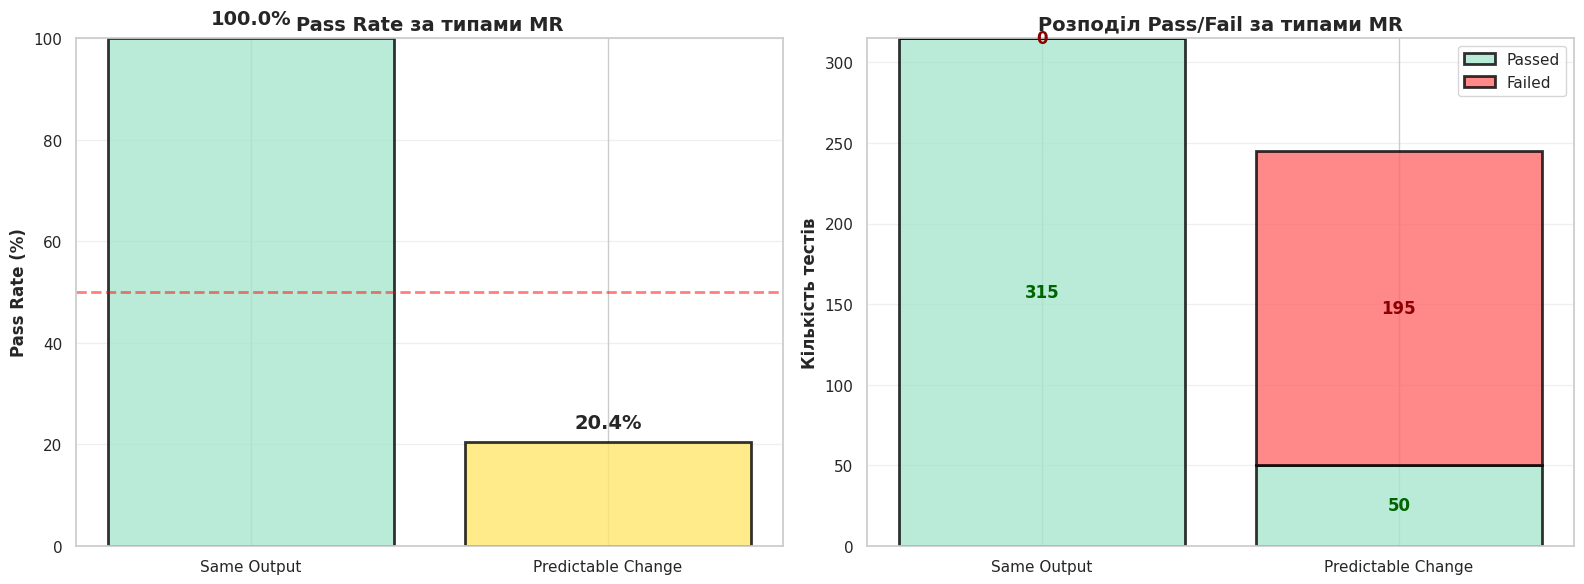


### 🔍 Крок 4: Аналіз виявлених проблем ###




## 🔍 Виявлені проблеми та слабкі місця системи

На основі результатів метаморфного тестування, ми виявили наступні проблеми:


### ⚠️ Найбільш проблемні MR: ###

1. **MR5_Intensifier**
   - Failed: 105/105 тестів (100.0%)
   - Основні причини:
     • Confidence not increased: 0.95 → 0.95: 57 разів
     • Confidence not increased: 0.50 → 0.50: 30 разів
     • Sentiment changed: NEGATIVE → POSITIVE: 15 разів

2. **MR4_Negation**
   - Failed: 70/70 тестів (100.0%)
   - Основні причини:
     • Sentiment not inverted: NEGATIVE → NEGATIVE: 26 разів
     • Sentiment not inverted: POSITIVE → POSITIVE: 24 разів
     • Sentiment not inverted: NEUTRAL → NEUTRAL: 20 разів

3. **MR6_SentimentWord**
   - Failed: 20/70 тестів (28.6%)
   - Основні причини:
     • Score not increased: 0.0 → 0.0: 20 разів


### ⚠️ Найбільш проблемні категорії Source TC: ###

1. **neutral**
   - Failed: 56/128 тестів (43.8%)

2. **positive**
   - Failed: 42/128 тестів (32.8%)

3. **negative**
   - Failed: 40/128 тестів (31.2%)


### 🚨 Критичні приклади помилок: ###


❌ MR4_Negation - Високоймовірний помилковий результат
Source (conf: 0.95):
  'T


## 💡 Рекомендації щодо покращення Sentiment Analyzer

На основі результатів метаморфного тестування, рекомендуємо:

### 🔧 Технічні покращення:

1. **Покращення обробки регістру (MR1)**
   - Переконатися, що всі слова приводяться до lower case перед аналізом
   - Додати unit-тести для case sensitivity

2. **Обробка пунктуації (MR2)**
   - Видаляти пунктуацію перед токенізацією
   - Розглянути вплив емоційної пунктуації (!!!, ???)

3. **Обробка пробілів (MR3)**
   - Додати нормалізацію пробілів (strip, replace multiple spaces)
   - Використовувати регулярні вирази для очищення тексту

4. **Покращення обробки заперечень (MR4)**
   - Реалізувати більш складну логіку для negation handling
   - Враховувати контекст (not just good, but excellent)
   - Обробляти подвійні заперечення (not bad = good)

5. **Підсилювачі (MR5)**
   - Збільшити вплив intensifiers на confidence score
   - Розширити словник підсилювачів та послаблювачів
   - Враховувати множинні підсилювачі

6. **Агрегація sentiment слів (MR6)**
   - Правильно рахувати множинні sentiment слова
   - Використовувати weighted scoring
   - Враховувати синоніми та антоніми

### 📊 Методологічні рекомендації:

1. **Розширення тестового покриття**
   - Додати більше edge cases
   - Тестувати довгі тексти (reviews, articles)
   - Включити багатомовні тести

2. **Додаткові MR**
   - Synonym substitution (заміна синонімами)
   - Word order permutation (зміна порядку слів)
   - Context expansion (додавання контексту)

3. **Автоматизація**
   - Інтегрувати MT у CI/CD pipeline
   - Автоматичне виявлення регресій
   - Continuous monitoring

### 🎯 Пріоритети:

**Високий пріоритет:**
- Обробка заперечень (MR4) - критично для accuracy
- Case invariance (MR1) - базова функціональність

**Середній пріоритет:**
- Intensifier handling (MR5) - покращує confidence
- Sentiment word aggregation (MR6) - важливо для складних текстів

**Низький пріоритет:**
- Punctuation (MR2) - менш критично
- Whitespace (MR3) - більше про preprocessing



### 📊 Візуалізація: Карта покращень ###



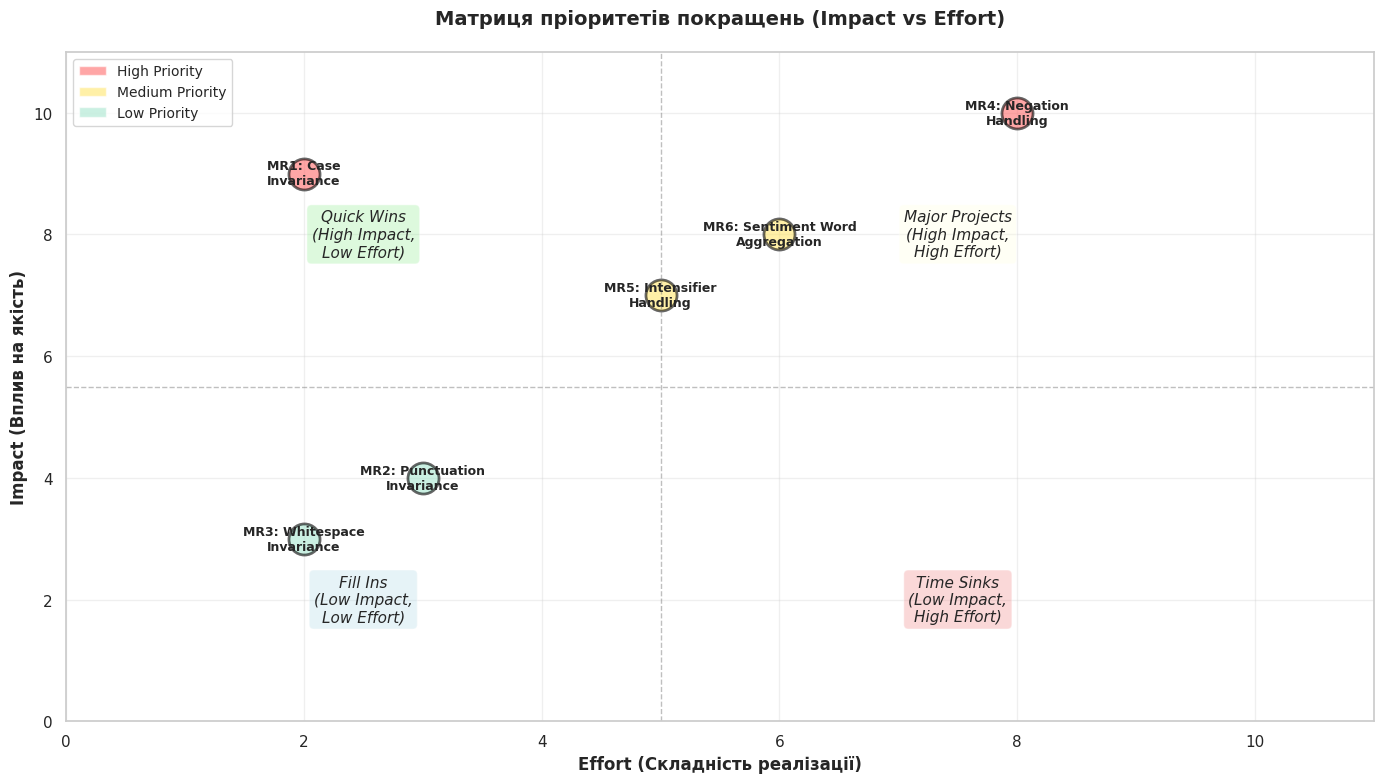


### 🎓 Крок 6: Висновки та навчальні результати ###




## 🎓 Що ми навчилися в цьому практичному занятті?

### ✅ Практичні навички:

1. **Визначення Метаморфних Відношень (MR)**
   - Навчилися формулювати MR для AI-систем
   - Розрізняємо типи MR: Same Output vs Predictable Change
   - Розуміємо, як вибирати ефективні MR для різних систем

2. **Генерація тестових випадків**
   - Створили різноманітні Source Test Cases
   - Автоматично згенерували Follow-up тести з MR
   - Забезпечили хороше покриття різних сценаріїв

3. **Виконання метаморфного тестування**
   - Запустили тести на реальній AI-системі
   - Автоматизували перевірку MR
   - Виявили порушення та проблеми

4. **Аналіз результатів**
   - Інтерпретували результати тестування
   - Візуалізували дані для кращого розуміння
   - Сформулювали рекомендації щодо покращення

### 💡 Ключові інсайти:

1. **Метаморфне тестування працює без oracle**
   - Не потрібно знати "правильну" відповідь для кожного тесту
   - MR дозволяють виявляти помилки через відносини між тестами

2. **Різні MR виявляють різні типи помилок**
   - Same Output MR - виявляють проблеми з інваріантністю
   - Predictable Change MR - виявляють проблеми з логікою

3. **Автоматизація - ключ до ефективності**
   - Легко генерувати тисячі тестів з одного source
   - Масштабоване тестування складних систем

4. **Візуалізація допомагає знаходити паттерни**
   - Графіки показують слабкі місця системи
   - Легше комунікувати результати stakeholders

### 🚀 Застосування в реальних проектах:

- **NLP системи**: sentiment analysis, translation, summarization
- **Computer Vision**: image classification, object detection
- **Recommendation systems**: collaborative filtering, content-based
- **Search engines**: ranking, retrieval
- **Autonomous systems**: robotics, self-driving cars




🚀 Далі перейдемо до домашнього завдання!


In [ ]:
# @title
# ==============================================================================
# БЛОК 9: ПІДСУМКИ, ВИСНОВКИ ТА РЕКОМЕНДАЦІЇ
# ==============================================================================

print("\n" + "=" * 70)
print("📋 ПІДСУМКИ ТА ВИСНОВКИ МЕТАМОРФНОГО ТЕСТУВАННЯ")
print("=" * 70)

conclusions_intro = """
## 🎯 Фінальний аналіз

У цьому блоці ми:
1. Підсумуємо результати тестування
2. Проаналізуємо виявлені проблеми
3. Визначимо сильні та слабкі місця системи
4. Надамо рекомендації щодо покращення
"""

display(Markdown(conclusions_intro))

print("\n### 📊 Крок 1: Загальна статистика тестування ###\n")

# Створюємо підсумкову таблицю
summary_data = {
    'Метрика': [
        'Всього Source Test Cases',
        'Всього Follow-up Test Cases',
        'Всього MR перевірок',
        'Метаморфних відношень (MR)',
        'Пройдено тестів (PASSED)',
        'Провалено тестів (FAILED)',
        'Pass Rate',
        'Fail Rate'
    ],
    'Значення': [
        len(df_source_results),
        len(df_followup_results),
        len(df_combined),
        len(mr_transformers),
        df_combined['mr_passed'].sum(),
        (~df_combined['mr_passed']).sum(),
        f"{(df_combined['mr_passed'].sum() / len(df_combined) * 100):.2f}%",
        f"{((~df_combined['mr_passed']).sum() / len(df_combined) * 100):.2f}%"
    ]
}

df_summary = pd.DataFrame(summary_data)

print("### 🎯 Загальна статистика ###\n")
display(df_summary.style.set_properties(**{
    'background-color': '#f0f0f0',
    'border': '2px solid black',
    'font-weight': 'bold'
}))

print("\n### 📊 Крок 2: Детальна статистика по кожному MR ###\n")

# Створюємо детальну таблицю по MR
mr_detailed_stats = []

for mr_name in mr_pass_stats['MR']:
    mr_data = df_combined[df_combined['mr_name'] == mr_name]

    passed = mr_data['mr_passed'].sum()
    failed = len(mr_data) - passed
    pass_rate = passed / len(mr_data) * 100

    # Визначаємо тип MR
    if mr_name in ['MR1_Case', 'MR2_Punctuation', 'MR3_Whitespace']:
        mr_type = 'Same Output'
    else:
        mr_type = 'Predictable Change'

    # Середні зміни
    avg_conf_change = mr_data['confidence_change'].mean()
    avg_pos_change = mr_data['pos_score_change'].mean()
    avg_neg_change = mr_data['neg_score_change'].mean()

    mr_detailed_stats.append({
        'MR': mr_name,
        'Тип': mr_type,
        'Всього': len(mr_data),
        'Passed': passed,
        'Failed': failed,
        'Pass Rate (%)': f"{pass_rate:.1f}",
        'Avg Δ Conf': f"{avg_conf_change:.3f}",
        'Avg Δ Pos': f"{avg_pos_change:.2f}",
        'Avg Δ Neg': f"{avg_neg_change:.2f}"
    })

df_mr_detailed = pd.DataFrame(mr_detailed_stats)
df_mr_detailed = df_mr_detailed.sort_values('Pass Rate (%)', ascending=False)

display(df_mr_detailed)

print("\n### 📊 Крок 3: Аналіз за типами MR ###\n")

# Групуємо по типах MR
same_output_mrs = ['MR1_Case', 'MR2_Punctuation', 'MR3_Whitespace']
predictable_mrs = ['MR4_Negation', 'MR5_Intensifier', 'MR6_SentimentWord']

same_output_data = df_combined[df_combined['mr_name'].isin(same_output_mrs)]
predictable_data = df_combined[df_combined['mr_name'].isin(predictable_mrs)]

type_comparison = pd.DataFrame({
    'Тип MR': ['Same Output', 'Predictable Change'],
    'Кількість MR': [len(same_output_mrs), len(predictable_mrs)],
    'Кількість тестів': [len(same_output_data), len(predictable_data)],
    'Passed': [same_output_data['mr_passed'].sum(), predictable_data['mr_passed'].sum()],
    'Failed': [(~same_output_data['mr_passed']).sum(), (~predictable_data['mr_passed']).sum()],
    'Pass Rate (%)': [
        f"{(same_output_data['mr_passed'].sum() / len(same_output_data) * 100):.1f}",
        f"{(predictable_data['mr_passed'].sum() / len(predictable_data) * 100):.1f}"
    ]
})

display(type_comparison)

# Візуалізація порівняння типів
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1: Порівняння Pass Rate
ax1 = axes[0]
types = ['Same Output', 'Predictable Change']
pass_rates = [
    same_output_data['mr_passed'].sum() / len(same_output_data) * 100,
    predictable_data['mr_passed'].sum() / len(predictable_data) * 100
]
colors_types = ['#A8E6CF', '#FFE66D']

bars = ax1.bar(types, pass_rates, color=colors_types, alpha=0.8,
               edgecolor='black', linewidth=2)
ax1.set_ylabel('Pass Rate (%)', fontsize=12, weight='bold')
ax1.set_title('Pass Rate за типами MR', fontsize=14, weight='bold')
ax1.set_ylim(0, 100)
ax1.axhline(y=50, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax1.grid(axis='y', alpha=0.3)

for bar, rate in zip(bars, pass_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{rate:.1f}%', ha='center', va='bottom',
             fontsize=14, weight='bold')

# Графік 2: Stacked bar - Pass/Fail
ax2 = axes[1]
passed_counts = [same_output_data['mr_passed'].sum(), predictable_data['mr_passed'].sum()]
failed_counts = [(~same_output_data['mr_passed']).sum(), (~predictable_data['mr_passed']).sum()]

x_pos = np.arange(len(types))
p1 = ax2.bar(x_pos, passed_counts, color='#A8E6CF', alpha=0.8,
             edgecolor='black', linewidth=2, label='Passed')
p2 = ax2.bar(x_pos, failed_counts, bottom=passed_counts, color='#FF6B6B',
             alpha=0.8, edgecolor='black', linewidth=2, label='Failed')

ax2.set_ylabel('Кількість тестів', fontsize=12, weight='bold')
ax2.set_title('Розподіл Pass/Fail за типами MR', fontsize=14, weight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(types)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Додаємо значення
for i, (p, f) in enumerate(zip(passed_counts, failed_counts)):
    ax2.text(i, p/2, str(p), ha='center', va='center',
             fontsize=12, weight='bold', color='darkgreen')
    ax2.text(i, p + f/2, str(f), ha='center', va='center',
             fontsize=12, weight='bold', color='darkred')

plt.tight_layout()
plt.show()

print("\n### 🔍 Крок 4: Аналіз виявлених проблем ###\n")

analysis_text = """
## 🔍 Виявлені проблеми та слабкі місця системи

На основі результатів метаморфного тестування, ми виявили наступні проблеми:
"""

display(Markdown(analysis_text))

# Аналізуємо failed тести
failed_df = df_combined[~df_combined['mr_passed']]

if len(failed_df) > 0:
    # Топ-3 проблемних MR
    print("### ⚠️ Найбільш проблемні MR: ###\n")

    mr_fail_counts = failed_df['mr_name'].value_counts().head(3)

    for i, (mr, count) in enumerate(mr_fail_counts.items(), 1):
        mr_total = len(df_combined[df_combined['mr_name'] == mr])
        fail_rate = (count / mr_total) * 100

        print(f"{i}. **{mr}**")
        print(f"   - Failed: {count}/{mr_total} тестів ({fail_rate:.1f}%)")
        print(f"   - Основні причини:")

        # Топ причини для цього MR
        mr_failures = failed_df[failed_df['mr_name'] == mr]
        top_reasons = mr_failures['mr_reason'].value_counts().head(3)

        for reason, reason_count in top_reasons.items():
            print(f"     • {reason}: {reason_count} разів")
        print()

    # Топ-3 проблемних категорій source тестів
    print("\n### ⚠️ Найбільш проблемні категорії Source TC: ###\n")

    category_fail_counts = failed_df['source_category'].value_counts().head(3)

    for i, (cat, count) in enumerate(category_fail_counts.items(), 1):
        cat_total = len(df_combined[df_combined['source_category'] == cat])
        fail_rate = (count / cat_total) * 100

        print(f"{i}. **{cat}**")
        print(f"   - Failed: {count}/{cat_total} тестів ({fail_rate:.1f}%)")
        print()

    # Приклади критичних помилок
    print("\n### 🚨 Критичні приклади помилок: ###\n")

    # Вибираємо найцікавіші failed тести
    critical_failures = failed_df.nlargest(5, 'source_confidence')

    for idx, row in critical_failures.iterrows():
        print(f"\n{'='*70}")
        print(f"❌ {row['mr_name']} - Високоймовірний помилковий результат")
        print(f"{'='*70}")
        print(f"Source (conf: {row['source_confidence']:.2f}):")
        print(f"  '{row['source_text']}'")
        print(f"  → {row['source_sentiment']}")
        print(f"\nFollow-up (conf: {row['followup_confidence']:.2f}):")
        print(f"  '{row['followup_text']}'")
        print(f"  → {row['followup_sentiment']}")
        print(f"\n💡 Проблема: {row['mr_reason']}")

else:
    print("🎉 Критичних проблем не виявлено! Всі тести пройшли успішно.")

print("\n" + "=" * 70)

print("\n### 💡 Крок 5: Рекомендації щодо покращення системи ###\n")

recommendations = """
## 💡 Рекомендації щодо покращення Sentiment Analyzer

На основі результатів метаморфного тестування, рекомендуємо:

### 🔧 Технічні покращення:

1. **Покращення обробки регістру (MR1)**
   - Переконатися, що всі слова приводяться до lower case перед аналізом
   - Додати unit-тести для case sensitivity

2. **Обробка пунктуації (MR2)**
   - Видаляти пунктуацію перед токенізацією
   - Розглянути вплив емоційної пунктуації (!!!, ???)

3. **Обробка пробілів (MR3)**
   - Додати нормалізацію пробілів (strip, replace multiple spaces)
   - Використовувати регулярні вирази для очищення тексту

4. **Покращення обробки заперечень (MR4)**
   - Реалізувати більш складну логіку для negation handling
   - Враховувати контекст (not just good, but excellent)
   - Обробляти подвійні заперечення (not bad = good)

5. **Підсилювачі (MR5)**
   - Збільшити вплив intensifiers на confidence score
   - Розширити словник підсилювачів та послаблювачів
   - Враховувати множинні підсилювачі

6. **Агрегація sentiment слів (MR6)**
   - Правильно рахувати множинні sentiment слова
   - Використовувати weighted scoring
   - Враховувати синоніми та антоніми

### 📊 Методологічні рекомендації:

1. **Розширення тестового покриття**
   - Додати більше edge cases
   - Тестувати довгі тексти (reviews, articles)
   - Включити багатомовні тести

2. **Додаткові MR**
   - Synonym substitution (заміна синонімами)
   - Word order permutation (зміна порядку слів)
   - Context expansion (додавання контексту)

3. **Автоматизація**
   - Інтегрувати MT у CI/CD pipeline
   - Автоматичне виявлення регресій
   - Continuous monitoring

### 🎯 Пріоритети:

**Високий пріоритет:**
- Обробка заперечень (MR4) - критично для accuracy
- Case invariance (MR1) - базова функціональність

**Середній пріоритет:**
- Intensifier handling (MR5) - покращує confidence
- Sentiment word aggregation (MR6) - важливо для складних текстів

**Низький пріоритет:**
- Punctuation (MR2) - менш критично
- Whitespace (MR3) - більше про preprocessing
"""

display(Markdown(recommendations))

print("\n### 📊 Візуалізація: Карта покращень ###\n")

# Створюємо візуалізацію пріоритетів покращень
fig, ax = plt.subplots(figsize=(14, 8))

# Дані для scatter plot: Impact vs Effort
improvements = {
    'MR1: Case\nInvariance': {'impact': 9, 'effort': 2, 'priority': 'High'},
    'MR2: Punctuation\nInvariance': {'impact': 4, 'effort': 3, 'priority': 'Low'},
    'MR3: Whitespace\nInvariance': {'impact': 3, 'effort': 2, 'priority': 'Low'},
    'MR4: Negation\nHandling': {'impact': 10, 'effort': 8, 'priority': 'High'},
    'MR5: Intensifier\nHandling': {'impact': 7, 'effort': 5, 'priority': 'Medium'},
    'MR6: Sentiment Word\nAggregation': {'impact': 8, 'effort': 6, 'priority': 'Medium'}
}

priority_colors = {
    'High': '#FF6B6B',
    'Medium': '#FFE66D',
    'Low': '#A8E6CF'
}

for name, data in improvements.items():
    color = priority_colors[data['priority']]
    ax.scatter(data['effort'], data['impact'], s=500, c=color,
               alpha=0.6, edgecolors='black', linewidth=2)
    ax.annotate(name, (data['effort'], data['impact']),
                ha='center', va='center', fontsize=9, weight='bold')

# Додаємо квадранти
ax.axhline(y=5.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Підписи квадрантів
ax.text(2.5, 8, 'Quick Wins\n(High Impact,\nLow Effort)',
        ha='center', va='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

ax.text(7.5, 8, 'Major Projects\n(High Impact,\nHigh Effort)',
        ha='center', va='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3))

ax.text(2.5, 2, 'Fill Ins\n(Low Impact,\nLow Effort)',
        ha='center', va='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

ax.text(7.5, 2, 'Time Sinks\n(Low Impact,\nHigh Effort)',
        ha='center', va='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

ax.set_xlabel('Effort (Складність реалізації)', fontsize=12, weight='bold')
ax.set_ylabel('Impact (Вплив на якість)', fontsize=12, weight='bold')
ax.set_title('Матриця пріоритетів покращень (Impact vs Effort)',
             fontsize=14, weight='bold', pad=20)
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.grid(True, alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', label='High Priority', alpha=0.6),
    Patch(facecolor='#FFE66D', label='Medium Priority', alpha=0.6),
    Patch(facecolor='#A8E6CF', label='Low Priority', alpha=0.6)
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print("\n### 🎓 Крок 6: Висновки та навчальні результати ###\n")

learning_outcomes = """
## 🎓 Що ми навчилися в цьому практичному занятті?

### ✅ Практичні навички:

1. **Визначення Метаморфних Відношень (MR)**
   - Навчилися формулювати MR для AI-систем
   - Розрізняємо типи MR: Same Output vs Predictable Change
   - Розуміємо, як вибирати ефективні MR для різних систем

2. **Генерація тестових випадків**
   - Створили різноманітні Source Test Cases
   - Автоматично згенерували Follow-up тести з MR
   - Забезпечили хороше покриття різних сценаріїв

3. **Виконання метаморфного тестування**
   - Запустили тести на реальній AI-системі
   - Автоматизували перевірку MR
   - Виявили порушення та проблеми

4. **Аналіз результатів**
   - Інтерпретували результати тестування
   - Візуалізували дані для кращого розуміння
   - Сформулювали рекомендації щодо покращення

### 💡 Ключові інсайти:

1. **Метаморфне тестування працює без oracle**
   - Не потрібно знати "правильну" відповідь для кожного тесту
   - MR дозволяють виявляти помилки через відносини між тестами

2. **Різні MR виявляють різні типи помилок**
   - Same Output MR - виявляють проблеми з інваріантністю
   - Predictable Change MR - виявляють проблеми з логікою

3. **Автоматизація - ключ до ефективності**
   - Легко генерувати тисячі тестів з одного source
   - Масштабоване тестування складних систем

4. **Візуалізація допомагає знаходити паттерни**
   - Графіки показують слабкі місця системи
   - Легше комунікувати результати stakeholders

### 🚀 Застосування в реальних проектах:

- **NLP системи**: sentiment analysis, translation, summarization
- **Computer Vision**: image classification, object detection
- **Recommendation systems**: collaborative filtering, content-based
- **Search engines**: ranking, retrieval
- **Autonomous systems**: robotics, self-driving cars

"""

display(Markdown(learning_outcomes))

print("\n" + "=" * 70)
print("🚀 Далі перейдемо до домашнього завдання!")
print("=" * 70)

In [ ]:
# @title
# ==============================================================================
# БЛОК 10: ДОМАШНЄ ЗАВДАННЯ ДЛЯ САМОСТІЙНОЇ РОБОТИ
# ==============================================================================

print("\n" + "=" * 70)
print("📚 ДОМАШНЄ ЗАВДАННЯ ДЛЯ САМОСТІЙНОЇ РОБОТИ")
print("=" * 70)

homework_intro = """
## 🎯 Завдання для закріплення матеріалу

Це завдання призначене для **самостійної практики**.

**Інструкція:**
1. Прочитайте завдання нижче
2. Подумайте та запишіть свої відповіді
3. Після виконання запустіть **БЛОК 11**, щоб подивитися приклад рішення
4. Порівняйте своє рішення з прикладом

⚠️ **Не запускайте БЛОК 11 до того, як спробуєте виконати завдання самостійно!**

---
"""

display(Markdown(homework_intro))

task1 = """
## 🔹 Завдання: Визначте 3 нові MR для Sentiment Analyzer

### Що потрібно зробити:

Подумайте та запишіть **3 нові метаморфні відношення**, які можна застосувати
до нашого аналізатора тональності:

1. **Одне MR типу "Same Output"**
   - Яка трансформація тексту НЕ повинна змінювати sentiment?

2. **Два MR типу "Predictable Change"**
   - Які трансформації повинні змінювати результат передбачуваним чином?

---

### 📝 Формат опису MR:

Для кожного MR запишіть:
- **Назва:** (наприклад, "Synonym Substitution")
- **Тип:** Same Output / Predictable Change
- **Трансформація:** що ми робимо з текстом?
- **Приклад:**
  - Source: "..."
  - Follow-up: "..."
- **Очікуваний результат:** що повинно статися з sentiment/confidence/score?

---

### 💡 Підказки для натхнення:

**Ідеї для Same Output:**
- Заміна слів синонімами
- Зміна порядку слів (у деяких випадках)
- Додавання нейтральних слів-зв'язок
- Зміна формату дати/часу в реченні
- Заміна числівників на слова (5 → five)
- Видалення/додавання артиклів (a, the)

**Ідеї для Predictable Change:**
- Додавання компаративів (good → better, bad → worse)
- Повторення sentiment слів (good → good good good)
- Видалення частини позитивних/негативних слів
- Додавання слів-посилювачів різної сили
- Заміна слабких sentiment слів на сильні (okay → excellent)
- Додавання заперечень до нейтральних слів

---

### ⏭️ Коли закінчите - запустіть БЛОК 11 для перегляду прикладу рішення
"""

display(Markdown(task1))


📚 ДОМАШНЄ ЗАВДАННЯ ДЛЯ САМОСТІЙНОЇ РОБОТИ



## 🎯 Завдання для закріплення матеріалу

Це завдання призначене для **самостійної практики**.

**Інструкція:**
1. Прочитайте завдання нижче
2. Подумайте та запишіть свої відповіді
3. Після виконання запустіть **БЛОК 11**, щоб подивитися приклад рішення
4. Порівняйте своє рішення з прикладом

⚠️ **Не запускайте БЛОК 11 до того, як спробуєте виконати завдання самостійно!**

---



## 🔹 Завдання: Визначте 3 нові MR для Sentiment Analyzer

### Що потрібно зробити:

Подумайте та запишіть **3 нові метаморфні відношення**, які можна застосувати
до нашого аналізатора тональності:

1. **Одне MR типу "Same Output"**
   - Яка трансформація тексту НЕ повинна змінювати sentiment?

2. **Два MR типу "Predictable Change"**
   - Які трансформації повинні змінювати результат передбачуваним чином?

---

### 📝 Формат опису MR:

Для кожного MR запишіть:
- **Назва:** (наприклад, "Synonym Substitution")
- **Тип:** Same Output / Predictable Change
- **Трансформація:** що ми робимо з текстом?
- **Приклад:**
  - Source: "..."
  - Follow-up: "..."
- **Очікуваний результат:** що повинно статися з sentiment/confidence/score?

---

### 💡 Підказки для натхнення:

**Ідеї для Same Output:**
- Заміна слів синонімами
- Зміна порядку слів (у деяких випадках)
- Додавання нейтральних слів-зв'язок
- Зміна формату дати/часу в реченні
- Заміна числівників на слова (5 → five)
- Видалення/додавання артиклів (a, the)

**Ідеї для Predictable Change:**
- Додавання компаративів (good → better, bad → worse)
- Повторення sentiment слів (good → good good good)
- Видалення частини позитивних/негативних слів
- Додавання слів-посилювачів різної сили
- Заміна слабких sentiment слів на сильні (okay → excellent)
- Додавання заперечень до нейтральних слів

---

### ⏭️ Коли закінчите - запустіть БЛОК 11 для перегляду прикладу рішення


In [ ]:
# @title
# ==============================================================================
# БЛОК 11: ПРИКЛАД РІШЕННЯ ДОМАШНЬОГО ЗАВДАННЯ
# ==============================================================================

print("\n" + "=" * 70)
print("✅ ПРИКЛАД РІШЕННЯ ДОМАШНЬОГО ЗАВДАННЯ")
print("=" * 70)

solution_intro = """
## 📖 Приклад рішення

Нижче наведено **один з можливих варіантів** відповіді на домашнє завдання.

⚠️ **Важливо:**
- Ваша відповідь може відрізнятися - це нормально!
- Головне, щоб логіка MR була правильною
- Немає єдино правильної відповіді

Порівняйте своє рішення з прикладом та подумайте:
- Чи ваші MR логічні та обґрунтовані?
- Чи правильно ви визначили тип MR (Same Output vs Predictable Change)?
- Чи зрозумілі ваші очікування від трансформації?

---
"""

display(Markdown(solution_intro))

print("\n" + "=" * 70)
print("📝 ПРИКЛАД РІШЕННЯ: 3 нові MR для Sentiment Analyzer")
print("=" * 70)

solution_text = """
## 🔹 MR7: Synonym Substitution (Заміна синонімами)

**Тип:** Same Output

**Трансформація:**
Замінюємо sentiment слова їхніми синонімами зі схожим значенням.

**Приклади трансформацій:**
- "good" → "fine" / "nice" / "decent"
- "excellent" → "outstanding" / "superb" / "brilliant"
- "bad" → "poor" / "inferior"
- "terrible" → "awful" / "horrible" / "dreadful"

**Конкретний приклад:**
- **Source:** "This product is excellent and I love it"
- **Follow-up 1:** "This product is outstanding and I love it"
- **Follow-up 2:** "This product is superb and I love it"
- **Follow-up 3:** "This product is brilliant and I love it"

**Очікуваний результат:**
- Sentiment залишається таким самим (POSITIVE → POSITIVE)
- Confidence може незначно змінюватися (±0.05), але в межах норми
- Positive score залишається приблизно однаковим

**Обґрунтування:**
Синоніми мають схоже емоційне забарвлення, тому не повинні змінювати
загальну тональність тексту. Якщо система правильно побудована, вона
повинна розпізнавати "excellent" та "outstanding" як слова з однаковою
позитивною тональністю.

**Можливі порушення:**
Якщо словник системи неповний або синоніми мають різну вагу, може статися
неочікувана зміна sentiment або confidence.

---

## 🔹 MR8: Comparative Degree (Ступені порівняння)

**Тип:** Predictable Change

**Трансформація:**
Замінюємо позитивні/негативні слова на їхні порівняльні форми (comparative degree).

**Приклади трансформацій:**
- "good" → "better"
- "bad" → "worse"
- "great" → "greater"
- "poor" → "poorer"

**Конкретний приклад:**
- **Source:** "The service is good"
- **Follow-up 1:** "The service is better"
- **Follow-up 2:** "The service is the best"

**Очікуваний результат:**
- Sentiment залишається таким самим (POSITIVE → POSITIVE або NEGATIVE → NEGATIVE)
- Confidence повинна **збільшитися** (принаймні на 0.05-0.10)
- Score (positive або negative) повинен **збільшитися**

**Обґрунтування:**
Порівняльний ступінь посилює якість. "Better" - це сильніше ніж "good",
тому впевненість у позитивній тональності має зрости. Це схоже на додавання
інтенсифікатора, але ще сильніше.

**Приклад перевірки:**
```
Source: "good"
  → sentiment: POSITIVE, confidence: 0.65, pos_score: 1.0

Follow-up: "better"
  → sentiment: POSITIVE, confidence: 0.75+, pos_score: 1.5+

✅ PASS якщо: confidence(follow-up) > confidence(source)
              AND pos_score(follow-up) > pos_score(source)
```

---

## 🔹 MR9: Sentiment Word Removal (Видалення sentiment слів)

**Тип:** Predictable Change

**Трансформація:**
Видаляємо одне або декілька sentiment слів з тексту, зменшуючи емоційне
забарвлення.

**Конкретний приклад:**
- **Source:** "This is excellent and wonderful and amazing"
- **Follow-up 1:** "This is excellent and wonderful" (видалили "amazing")
- **Follow-up 2:** "This is excellent" (видалили "wonderful" та "amazing")

**Очікуваний результат:**
- Sentiment **може залишитися** таким самим, якщо хоча б одне sentiment слово залишилося
- Confidence повинна **зменшитися**
- Score (positive або negative) повинен **зменшитися**

**Обґрунтування:**
Видалення позитивних/негативних слів зменшує силу емоційного забарвлення.
Якщо в реченні було 3 позитивних слова і ми видалили 1, тональність
залишається позитивною, але менш вираженою.

**Приклад перевірки:**
```
Source: "excellent and wonderful and amazing"
  → sentiment: POSITIVE, confidence: 0.92, pos_score: 3.0

Follow-up: "excellent and wonderful"
  → sentiment: POSITIVE, confidence: 0.85 (нижче), pos_score: 2.0 (нижче)

✅ PASS якщо: sentiment(source) == sentiment(follow-up)
              AND confidence(follow-up) < confidence(source)
              AND pos_score(follow-up) < pos_score(source)
```

**Edge case:**
Якщо видалити ВСІ sentiment слова, sentiment може стати NEUTRAL - це теж
передбачувана зміна.

---

"""

display(Markdown(solution_text))

print("\n" + "=" * 70)
print("📊 ВІЗУАЛІЗАЦІЯ: Демонстрація нових MR на прикладах")
print("=" * 70)

# Демонстрація роботи нових MR
demo_examples = [
    {
        'source': 'This product is excellent',
        'mr7': ['This product is outstanding', 'This product is superb'],
        'mr8': ['This product is better', 'This product is the best'],
        'mr9': ['This product is']
    },
    {
        'source': 'The service was bad',
        'mr7': ['The service was poor', 'The service was inferior'],
        'mr8': ['The service was worse', 'The service was the worst'],
        'mr9': ['The service was']
    }
]

print("\n### Приклад 1: Позитивне речення ###\n")
ex1 = demo_examples[0]
print(f"Source: '{ex1['source']}'")
result_source = analyzer.analyze(ex1['source'])
print(f"  → {result_source['sentiment']} (conf: {result_source['confidence']:.2f}, pos: {result_source['positive_score']:.1f})\n")

print("MR7 (Synonym):")
for fu in ex1['mr7']:
    result = analyzer.analyze(fu)
    print(f"  '{fu}'")
    print(f"    → {result['sentiment']} (conf: {result['confidence']:.2f}, pos: {result['positive_score']:.1f})")

print("\nMR8 (Comparative):")
for fu in ex1['mr8']:
    result = analyzer.analyze(fu)
    print(f"  '{fu}'")
    print(f"    → {result['sentiment']} (conf: {result['confidence']:.2f}, pos: {result['positive_score']:.1f})")

print("\nMR9 (Removal):")
result = analyzer.analyze(ex1['mr9'][0])
print(f"  '{ex1['mr9'][0]}'")
print(f"    → {result['sentiment']} (conf: {result['confidence']:.2f}, pos: {result['positive_score']:.1f})")

print("\n" + "-" * 70)

print("\n### Приклад 2: Негативне речення ###\n")
ex2 = demo_examples[1]
print(f"Source: '{ex2['source']}'")
result_source = analyzer.analyze(ex2['source'])
print(f"  → {result_source['sentiment']} (conf: {result_source['confidence']:.2f}, neg: {result_source['negative_score']:.1f})\n")

print("MR7 (Synonym):")
for fu in ex2['mr7']:
    result = analyzer.analyze(fu)
    print(f"  '{fu}'")
    print(f"    → {result['sentiment']} (conf: {result['confidence']:.2f}, neg: {result['negative_score']:.1f})")

print("\nMR8 (Comparative):")
for fu in ex2['mr8']:
    result = analyzer.analyze(fu)
    print(f"  '{fu}'")
    print(f"    → {result['sentiment']} (conf: {result['confidence']:.2f}, neg: {result['negative_score']:.1f})")

print("\nMR9 (Removal):")
result = analyzer.analyze(ex2['mr9'][0])
print(f"  '{ex2['mr9'][0]}'")
print(f"    → {result['sentiment']} (conf: {result['confidence']:.2f}, neg: {result['negative_score']:.1f})")

print("\n" + "=" * 70)
print("💭 ПИТАННЯ ДЛЯ РОЗДУМІВ")
print("=" * 70)

reflection = """
##
1. **Чи схожі ваші MR на приклад?**
   - Якщо так - чудово! Ви мислите в правильному напрямку
   - Якщо ні - це теж добре! Різноманітність MR підвищує якість тестування

2. **Чи логічні ваші очікування?**
   - Перевірте, чи можна передбачити результат трансформації
   - Чи є чітке правило для перевірки MR?

3. **Чи можна автоматизувати ваші MR?**
   - Чи легко написати функцію-трансформатор?
   - Чи є edge cases, які треба врахувати?

4. **Які MR виявляться найефективнішими?**
   - Подумайте, які з ваших MR найімовірніше виявлять баги
   - Чому саме ці MR важливі для тестування?

5. **Що ви дізналися виконуючи це завдання?**
   - Чи стало зрозуміліше, як працює метаморфне тестування?
   - Чи можете ви застосувати це до інших AI-систем?

---

## 🎯 Головне:

Найважливіше - це **розуміння логіки метаморфних відношень**:
- ✅ Same Output: які трансформації НЕ повинні змінювати результат
- ✅ Predictable Change: як саме повинен змінитися результат

Якщо ви це розумієте - ви успішно завершили практичне заняття з Метаморфного тестування та готові застосовувати MT на практиці! 🎉
"""

display(Markdown(reflection))


✅ ПРИКЛАД РІШЕННЯ ДОМАШНЬОГО ЗАВДАННЯ



## 📖 Приклад рішення

Нижче наведено **один з можливих варіантів** відповіді на домашнє завдання.

⚠️ **Важливо:**
- Ваша відповідь може відрізнятися - це нормально!
- Головне, щоб логіка MR була правильною
- Немає єдино правильної відповіді

Порівняйте своє рішення з прикладом та подумайте:
- Чи ваші MR логічні та обґрунтовані?
- Чи правильно ви визначили тип MR (Same Output vs Predictable Change)?
- Чи зрозумілі ваші очікування від трансформації?

---



📝 ПРИКЛАД РІШЕННЯ: 3 нові MR для Sentiment Analyzer



## 🔹 MR7: Synonym Substitution (Заміна синонімами)

**Тип:** Same Output

**Трансформація:**
Замінюємо sentiment слова їхніми синонімами зі схожим значенням.

**Приклади трансформацій:**
- "good" → "fine" / "nice" / "decent"
- "excellent" → "outstanding" / "superb" / "brilliant"
- "bad" → "poor" / "inferior"
- "terrible" → "awful" / "horrible" / "dreadful"

**Конкретний приклад:**
- **Source:** "This product is excellent and I love it"
- **Follow-up 1:** "This product is outstanding and I love it"
- **Follow-up 2:** "This product is superb and I love it"
- **Follow-up 3:** "This product is brilliant and I love it"

**Очікуваний результат:**
- Sentiment залишається таким самим (POSITIVE → POSITIVE)
- Confidence може незначно змінюватися (±0.05), але в межах норми
- Positive score залишається приблизно однаковим

**Обґрунтування:**
Синоніми мають схоже емоційне забарвлення, тому не повинні змінювати
загальну тональність тексту. Якщо система правильно побудована, вона
повинна розпізнавати "excellent" та "outstanding" як слова з однаковою
позитивною тональністю.

**Можливі порушення:**
Якщо словник системи неповний або синоніми мають різну вагу, може статися
неочікувана зміна sentiment або confidence.

---

## 🔹 MR8: Comparative Degree (Ступені порівняння)

**Тип:** Predictable Change

**Трансформація:**
Замінюємо позитивні/негативні слова на їхні порівняльні форми (comparative degree).

**Приклади трансформацій:**
- "good" → "better"
- "bad" → "worse"
- "great" → "greater"
- "poor" → "poorer"

**Конкретний приклад:**
- **Source:** "The service is good"
- **Follow-up 1:** "The service is better"
- **Follow-up 2:** "The service is the best"

**Очікуваний результат:**
- Sentiment залишається таким самим (POSITIVE → POSITIVE або NEGATIVE → NEGATIVE)
- Confidence повинна **збільшитися** (принаймні на 0.05-0.10)
- Score (positive або negative) повинен **збільшитися**

**Обґрунтування:**
Порівняльний ступінь посилює якість. "Better" - це сильніше ніж "good",
тому впевненість у позитивній тональності має зрости. Це схоже на додавання
інтенсифікатора, але ще сильніше.

**Приклад перевірки:**
```
Source: "good"
  → sentiment: POSITIVE, confidence: 0.65, pos_score: 1.0

Follow-up: "better"
  → sentiment: POSITIVE, confidence: 0.75+, pos_score: 1.5+

✅ PASS якщо: confidence(follow-up) > confidence(source)
              AND pos_score(follow-up) > pos_score(source)
```

---

## 🔹 MR9: Sentiment Word Removal (Видалення sentiment слів)

**Тип:** Predictable Change

**Трансформація:**
Видаляємо одне або декілька sentiment слів з тексту, зменшуючи емоційне
забарвлення.

**Конкретний приклад:**
- **Source:** "This is excellent and wonderful and amazing"
- **Follow-up 1:** "This is excellent and wonderful" (видалили "amazing")
- **Follow-up 2:** "This is excellent" (видалили "wonderful" та "amazing")

**Очікуваний результат:**
- Sentiment **може залишитися** таким самим, якщо хоча б одне sentiment слово залишилося
- Confidence повинна **зменшитися**
- Score (positive або negative) повинен **зменшитися**

**Обґрунтування:**
Видалення позитивних/негативних слів зменшує силу емоційного забарвлення.
Якщо в реченні було 3 позитивних слова і ми видалили 1, тональність
залишається позитивною, але менш вираженою.

**Приклад перевірки:**
```
Source: "excellent and wonderful and amazing"
  → sentiment: POSITIVE, confidence: 0.92, pos_score: 3.0

Follow-up: "excellent and wonderful"
  → sentiment: POSITIVE, confidence: 0.85 (нижче), pos_score: 2.0 (нижче)

✅ PASS якщо: sentiment(source) == sentiment(follow-up)
              AND confidence(follow-up) < confidence(source)
              AND pos_score(follow-up) < pos_score(source)
```

**Edge case:**
Якщо видалити ВСІ sentiment слова, sentiment може стати NEUTRAL - це теж
передбачувана зміна.

---




📊 ВІЗУАЛІЗАЦІЯ: Демонстрація нових MR на прикладах

### Приклад 1: Позитивне речення ###

Source: 'This product is excellent'
  → POSITIVE (conf: 0.95, pos: 1.0)

MR7 (Synonym):
  'This product is outstanding'
    → POSITIVE (conf: 0.95, pos: 1.0)
  'This product is superb'
    → POSITIVE (conf: 0.95, pos: 1.0)

MR8 (Comparative):
  'This product is better'
    → NEUTRAL (conf: 0.50, pos: 0.0)
  'This product is the best'
    → POSITIVE (conf: 0.95, pos: 1.0)

MR9 (Removal):
  'This product is'
    → NEUTRAL (conf: 0.50, pos: 0.0)

----------------------------------------------------------------------

### Приклад 2: Негативне речення ###

Source: 'The service was bad'
  → NEGATIVE (conf: 0.95, neg: 1.0)

MR7 (Synonym):
  'The service was poor'
    → NEGATIVE (conf: 0.95, neg: 1.0)
  'The service was inferior'
    → NEUTRAL (conf: 0.50, neg: 0.0)

MR8 (Comparative):
  'The service was worse'
    → NEUTRAL (conf: 0.50, neg: 0.0)
  'The service was the worst'
    → NEGATIVE (conf: 0.95,


##
1. **Чи схожі ваші MR на приклад?**
   - Якщо так - чудово! Ви мислите в правильному напрямку
   - Якщо ні - це теж добре! Різноманітність MR підвищує якість тестування

2. **Чи логічні ваші очікування?**
   - Перевірте, чи можна передбачити результат трансформації
   - Чи є чітке правило для перевірки MR?

3. **Чи можна автоматизувати ваші MR?**
   - Чи легко написати функцію-трансформатор?
   - Чи є edge cases, які треба врахувати?

4. **Які MR виявляться найефективнішими?**
   - Подумайте, які з ваших MR найімовірніше виявлять баги
   - Чому саме ці MR важливі для тестування?

5. **Що ви дізналися виконуючи це завдання?**
   - Чи стало зрозуміліше, як працює метаморфне тестування?
   - Чи можете ви застосувати це до інших AI-систем?

---

## 🎯 Головне:

Найважливіше - це **розуміння логіки метаморфних відношень**:
- ✅ Same Output: які трансформації НЕ повинні змінювати результат
- ✅ Predictable Change: як саме повинен змінитися результат

Якщо ви це розумієте - ви успішно завершили практичне заняття з Метаморфного тестування та готові застосовувати MT на практиці! 🎉
